# Лабораторная работа №2
# Временные ряды: Прогнозирование температуры

**Цель работы:** Извлечение данных из Excel-файла с несколькими листами, очистка и обработка многомерного временного ряда погоды, построение и оценка моделей машинного обучения для многошагового прогнозирования температуры (горизонт — 1 неделя).

**Стратегии прогнозирования:**
- Рекурсивная (recursive) стратегия
- Стратегия отдельной модели на каждый горизонт (direct / MIMO)

**Используемые модели:** Decision Tree, Random Forest, Gradient Boosting (XGBoost / LightGBM)  
**Подбор гиперпараметров:** Optuna


## 0. Подключение Google Drive и установка зависимостей

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive подключён.')

Mounted at /content/drive
Google Drive подключён.


In [3]:
!pip install -q optuna lightgbm xgboost statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


## 1. Импорт библиотек

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from pathlib import Path
from scipy import stats
from scipy.fft import fft, fftfreq
from scipy.signal import periodogram

import openpyxl

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print('Optuna не установлена, будут использованы параметры по умолчанию')

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

RANDOM_STATE = 42
HORIZON = 7
WINDOW = 21
TARGET_COL = 'temperature_2m'
DATE_COL   = 'ds'
CITY_COL   = 'city'

print('Все необходимые библиотеки загружены.')
print(f'Optuna: {OPTUNA_AVAILABLE} | LightGBM: {LGB_AVAILABLE} | XGBoost: {XGB_AVAILABLE}')

Все необходимые библиотеки загружены.
Optuna: True | LightGBM: True | XGBoost: True


## 2. Извлечение данных из Excel

Файл содержит **ровно 3 листа** с временными рядами. Часть листов скрыта. Используем `openpyxl` для доступа ко всем листам, включая скрытые.

In [5]:
EXCEL_PATH = '/content/drive/MyDrive/Frameworks2/have_fun.xlsx'

wb = openpyxl.load_workbook(EXCEL_PATH)

print(f'Всего листов в книге: {len(wb.sheetnames)}')
for sh in wb.sheetnames:
    ws = wb[sh]
    state = ws.sheet_state
    n_rows = sum(1 for row in ws.iter_rows(values_only=True)
                 if not all(v is None for v in row))
    print(f'  Лист: "{sh}"  |  Состояние: {state}  |  Непустых строк: {n_rows}')

Всего листов в книге: 8
  Лист: "Ëèñò1"  |  Состояние: visible  |  Непустых строк: 125125
  Лист: "Лист1"  |  Состояние: visible  |  Непустых строк: 0
  Лист: "ÌÀÈ"  |  Состояние: visible  |  Непустых строк: 0
  Лист: "ýòî"  |  Состояние: visible  |  Непустых строк: 0
  Лист: "ÿ"  |  Состояние: visible  |  Непустых строк: 0
  Лист: "!"  |  Состояние: visible  |  Непустых строк: 0
  Лист: "Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû"  |  Состояние: hidden  |  Непустых строк: 122718
  Лист: "Ëèñò3_ñìåøàííûå_òèïû"  |  Состояние: hidden  |  Непустых строк: 122737


In [6]:
def fix_encoding(s):
    if not isinstance(s, str):
        return s
    try:
        return s.encode('cp1252').decode('cp1251')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s


def read_sheet(wb, sheet_name):
    ws = wb[sheet_name]
    data = []
    headers = None
    for row in ws.iter_rows(values_only=True):
        if all(v is None for v in row):
            continue
        if headers is None:
            headers = [str(c).strip() if c is not None else f'col_{j}'
                       for j, c in enumerate(row)]
        else:
            data.append(row)
    df = pd.DataFrame(data, columns=headers)
    ghost_cols = [c for c in df.columns
                  if c.startswith('col_') and df[c].isna().all()]
    df = df.drop(columns=ghost_cols)
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].map(lambda x: fix_encoding(x) if isinstance(x, str) else x)
    return df

DATA_SHEET_NAMES = []
for sh in wb.sheetnames:
    ws = wb[sh]
    n = sum(1 for row in ws.iter_rows(values_only=True)
            if not all(v is None for v in row))
    if n > 100:
        DATA_SHEET_NAMES.append(sh)

print(f'Листов с данными: {len(DATA_SHEET_NAMES)}')
sheet_dfs = {}
for sh in DATA_SHEET_NAMES:
    df_raw = read_sheet(wb, sh)
    sheet_dfs[sh] = df_raw
    print(f'  "{sh}": {df_raw.shape}  |  Колонки: {list(df_raw.columns)}')

Листов с данными: 3
  "Ëèñò1": (125124, 10)  |  Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
  "Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû": (122717, 24)  |  Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_24']
  "Ëèñò3_ñìåøàííûå_òèïû": (122736, 10)  |  Колонки: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']


In [7]:
for name, df in sheet_dfs.items():
    print(f'\n=== Лист: {name} ===')
    display(df.head(10))


=== Лист: Ëèñò1 ===


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.800000,82.0,0.0,0.0,0.0,3.0,19.100000,1010.000000,2020-01-31 02:00:00,Геленджик
1,-3.000000,70.0,0.0,0.0,0.0,3.0,24.000000,981.900024,2025-02-28 09:00:00,Благовещенск
2,-1.300000,86.0,0.0,0.0,0.0,2.0,8.800000,1021.200012,2022-01-03 02:00:00,Геленджик
3,19.299999,49.0,0.0,0.0,0.0,0.0,22.799999,1016.200012,2020-09-17 06:00:00,Геленджик
4,9.600000,89.0,0.0,0.0,0.0,0.0,8.800000,1024.400024,2025-04-16 05:00:00,Геленджик
5,21.600000,78.0,0.0,0.0,0.0,1.0,11.800000,1012.799988,2021-08-21 04:00:00,Геленджик
6,14.600000,58.0,0.0,0.0,0.0,3.0,12.300000,1000.099976,2019-09-10 14:00:00,Благовещенск
7,5.400000,94.0,0.0,0.0,0.0,1.0,6.600000,1019.299988,2020-03-21 06:00:00,Геленджик
8,-15.900000,41.0,0.0,0.0,0.0,3.0,7.700000,1010.799988,2021-03-06 21:00:00,Благовещенск
9,4.400000,19.0,0.0,0.0,0.0,2.0,24.000000,991.900024,2022-03-29 16:00:00,Благовещенск



=== Лист: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû ===


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,...,col_15,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24
0,-6.5,92.0,0.0,0.0,0.0,3.0,10.8,1000.500000,2019-01-01 00:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
1,-6.8,92.0,0.0,0.0,0.0,3.0,10.5,1000.299988,2019-01-01 01:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
2,-6.8,92.0,0.0,0.0,0.0,3.0,10.8,1000.000000,2019-01-01 02:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
3,-5.8,93.0,0.0,0.0,0.0,3.0,12.2,999.299988,2019-01-01 03:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
4,79.276929,93.0,0.0,0.0,0.0,3.0,14.4,998.599976,2019-01-01 04:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
5,-5.8,92.0,0.0,0.0,0.0,3.0,15.5,997.599976,2019-01-01 05:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
6,-5.6,92.0,0.0,0.0,0.0,3.0,16.0,997.000000,2019-01-01 06:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
7,-5.2,91.0,0.0,0.0,0.0,3.0,17.200001,996.299988,2019-01-01 07:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
8,-5.1,91.0,0.0,0.0,0.0,3.0,19.4,995.599976,2019-01-01 08:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None
9,-5.1,90.0,0.0,0.0,0.0,3.0,22.299999,994.400024,2019-01-01 09:00:00,Москва,...,None,None,None,None,None,None,None,None,None,None



=== Лист: Ëèñò3_ñìåøàííûå_òèïû ===


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-1.8,85.0,0.0,0.0,0.00,3.0,23.5,1015.200012,2019-01-01 00:00:00,Санкт-Петербург
1,-1.9,83.0,0.0,0.0,0.00,3.0,26.0,1013.200012,2019-01-01 01:00:00,Санкт-Петербург
2,-2.0,85.0,0.0,0.0,0.00,3.0,26.200001,1011.700012,2019-01-01 02:00:00,Санкт-Петербург
3,-2.3,86.0,0.0,0.0,0.00,3.0,26.9,1009.900024,2019-01-01 03:00:00,Санкт-Петербург
4,-2.3,86.0,0.2,0.0,0.14,71.0,27.9,1007.700012,2019-01-01 04:00:00,Санкт-Петербург
5,-2.4,85.0,0.3,0.0,0.21,73.0,29.6,1005.099976,2019-01-01 05:00:00,Санкт-Петербург
6,-2.3,85.0,0.3,0.0,0.21,73.0,30.299999,1002.900024,2019-01-01 06:00:00,Санкт-Петербург
7,-2.2,84.0,0.2,0.0,0.14,71.0,31.799999,1000.700012,2019-01-01 07:00:00,Санкт-Петербург
8,-2.1,85.0,0.3,0.0,0.21,73.0,31.6,999.000000,2019-01-01 08:00:00,Санкт-Петербург
9,-1.9,85.0,0.3,0.0,0.21,73.0,31.200001,997.099976,2019-01-01 09:00:00,Санкт-Петербург


## 3. Очистка и унификация данных

Типичные проблемы в таких файлах:
- Разные форматы дат (строки, числа Excel, datetime)
- Опечатки в числах (запятые вместо точек, пробелы, русские буквы)
- Пропущенные значения (NaN, пустые ячейки, «-», «н/д»)
- Выбросы (аномальные значения температуры, влажности и т.д.)
- Дублированные строки
- Нарушение монотонности временного индекса

In [8]:
def clean_numeric(series):
    s = series.astype(str)
    s = s.str.replace(',', '.', regex=False)
    s = s.str.replace('\xa0', '', regex=False)
    s = s.str.strip()
    s = s.replace({'None': np.nan, 'nan': np.nan, 'н/д': np.nan,
                   '-': np.nan, '': np.nan, 'null': np.nan})
    return pd.to_numeric(s, errors='coerce')


def parse_date_col(series):
    parsed = pd.to_datetime(series, errors='coerce', dayfirst=True)
    mask_num = parsed.isna() & pd.to_numeric(series, errors='coerce').notna()
    if mask_num.any():
        excel_nums = pd.to_numeric(series[mask_num], errors='coerce')
        valid_mask = (excel_nums >= 1) & (excel_nums <= 73050)
        valid_idx = excel_nums.index[valid_mask]
        if valid_mask.any():
            good_nums = excel_nums[valid_mask]
            excel_dates = pd.TimedeltaIndex(good_nums - 2, unit='d') + pd.Timestamp('1900-01-01')
            parsed[valid_idx] = excel_dates.values
    return parsed


def clean_sheet(df, date_col, target_col, city_col, city_name):
    df = df.copy()

    df[date_col] = parse_date_col(df[date_col].astype(str)
                                   if df[date_col].dtype == object
                                   else df[date_col])
    df = df.dropna(subset=[date_col])

    num_cols = [c for c in df.columns if c not in [date_col, city_col]]
    for col in num_cols:
        if df[col].dtype == object:
            df[col] = clean_numeric(df[col])
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in num_cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lo, hi = Q1 - 3 * IQR, Q3 + 3 * IQR
        n_out = ((df[col] < lo) | (df[col] > hi)).sum()
        if n_out > 0:
            print(f'  [{city_name}] "{col}": {n_out} выбросов → NaN')
            df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan

    df['date'] = df[date_col].dt.normalize()
    df = df.drop(columns=[date_col])
    if city_col in df.columns:
        df = df.drop(columns=[city_col])
    df = df.groupby('date').mean(numeric_only=True)
    df.index.name = 'date'

    dupes = df.index.duplicated()
    if dupes.sum() > 0:
        print(f'  [{city_name}] Дубликатов дат после агрегации: {dupes.sum()}')
        df = df.groupby(df.index).mean()

    df = df.sort_index()

    pct_before = df.isna().mean().mean() * 100
    df = df.interpolate(method='time', limit_direction='both')
    df = df.ffill().bfill()
    pct_after = df.isna().mean().mean() * 100
    print(f'  [{city_name}] {df.shape[0]} дней  |  '
          f'Пропуски: {pct_before:.1f}% → {pct_after:.1f}%  |  '
          f'{df.index.min().date()} – {df.index.max().date()}')

    df['city'] = city_name
    return df

print('Функции очистки определены.')

Функции очистки определены.


In [9]:
clean_dfs = {}
for sheet_name in DATA_SHEET_NAMES:
    df_raw = sheet_dfs[sheet_name]

    city_name = 'Unknown'
    if CITY_COL in df_raw.columns:
        city_vals = df_raw[CITY_COL].dropna().unique()
        if len(city_vals) > 0:
            city_name = city_vals[0]

    print(f'\nОбработка листа: "{sheet_name}"  →  город: {city_name}')
    try:
        df_clean = clean_sheet(df_raw,
                               date_col=DATE_COL,
                               target_col=TARGET_COL,
                               city_col=CITY_COL,
                               city_name=city_name)
        clean_dfs[city_name] = df_clean
    except Exception as e:
        print(f'  ОШИБКА: {e}')
        import traceback; traceback.print_exc()


Обработка листа: "Ëèñò1"  →  город: Геленджик
  [Геленджик] "precipitation": 18392 выбросов → NaN
  [Геленджик] "rain": 15919 выбросов → NaN
  [Геленджик] "snowfall": 3159 выбросов → NaN
  [Геленджик] "weathercode": 18618 выбросов → NaN
  [Геленджик] "wind_speed_10m": 178 выбросов → NaN
  [Геленджик] 2557 дней  |  Пропуски: 0.0% → 0.0%  |  2019-01-01 – 2025-12-31

Обработка листа: "Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû"  →  город: Москва
  [Москва] "temperature_2m": 224 выбросов → NaN
  [Москва] "precipitation": 19096 выбросов → NaN
  [Москва] "rain": 13571 выбросов → NaN
  [Москва] "snowfall": 5854 выбросов → NaN
  [Москва] "weathercode": 18817 выбросов → NaN
  [Москва] "wind_speed_10m": 645 выбросов → NaN
  [Москва] "surface_pressure": 389 выбросов → NaN
  [Москва] "col_14": 3 выбросов → NaN
  [Москва] "col_17": 3 выбросов → NaN
  [Москва] "col_19": 3 выбросов → NaN
  [Москва] "col_20": 10 выбросов → NaN
  [Москва] 2557 дней  |  Пропуски: 63.5% → 22.7%  |  2019-01-01 – 2025-12-31

Обработка л

In [10]:
all_cities = pd.concat(clean_dfs.values(), axis=0)
all_cities = all_cities.sort_index()

print('Итоговый датафрейм:')
print(f'  Строк: {len(all_cities)}, Столбцов: {len(all_cities.columns)}')
print(f'  Города: {all_cities[CITY_COL].unique()}')
print(f'  Период: {all_cities.index.min().date()} – {all_cities.index.max().date()}')
display(all_cities.head(6))

Итоговый датафрейм:
  Строк: 7671, Столбцов: 23
  Города: ['Геленджик' 'Санкт-Петербург' 'Москва']
  Период: 2019-01-01 – 2025-12-31


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city,col_11,...,col_15,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24
date,,,,,,,,,,,,,,,,,,,,,
2019-01-01,-5.229787,75.625000,0.0,0.0,0.0,1.275000,10.466667,1016.216665,Геленджик,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01,1.900000,85.937500,0.0,0.0,0.0,2.000000,17.089583,1010.393752,Санкт-Петербург,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01,-8.115217,68.645833,0.0,0.0,0.0,1.309524,14.274468,1006.841665,Москва,NaN,...,5.390909,62.090909,0.0,0.0,0.0,2.727273,6.009091,1024.581798,NaN,NaN
2019-01-02,-5.808163,80.122449,0.0,0.0,0.0,0.500000,13.804082,1012.614286,Геленджик,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,3.447917,79.145833,0.0,0.0,0.0,2.233333,13.108511,1004.885419,Санкт-Петербург,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,-7.240426,68.104167,0.0,0.0,0.0,0.677419,18.097826,1002.337503,Москва,NaN,...,-7.783333,64.666667,0.0,0.0,0.0,1.166667,7.341667,1018.829165,NaN,NaN


In [11]:
print('Столбцы:', all_cities.columns.tolist())
print(f'Целевая переменная: "{TARGET_COL}" (среднесуточная температура)')

display(all_cities.drop(columns=[CITY_COL]).describe().T)

Столбцы: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'city', 'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_24']
Целевая переменная: "temperature_2m" (среднесуточная температура)


,count,mean,std,min,25%,50%,75%,max
temperature_2m,7671.0,8.683603,10.097954,-19.639583,1.004233,8.827660,17.845257,30.219149
relative_humidity_2m,7671.0,74.024021,8.748531,34.312500,68.270833,74.916667,80.520833,94.916667
precipitation,7671.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
rain,7671.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
snowfall,7671.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
weathercode,7671.0,1.596094,0.698973,0.000000,1.085410,1.564103,2.109903,3.000000
wind_speed_10m,7671.0,11.774986,3.627978,3.037255,9.130602,11.306383,13.895743,31.613043
surface_pressure,7671.0,1006.878160,8.189321,971.837036,1000.741668,1006.589582,1012.821498,1035.124997
col_11,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
col_12,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.1 Проверка пропусков в итоговом датафрейме

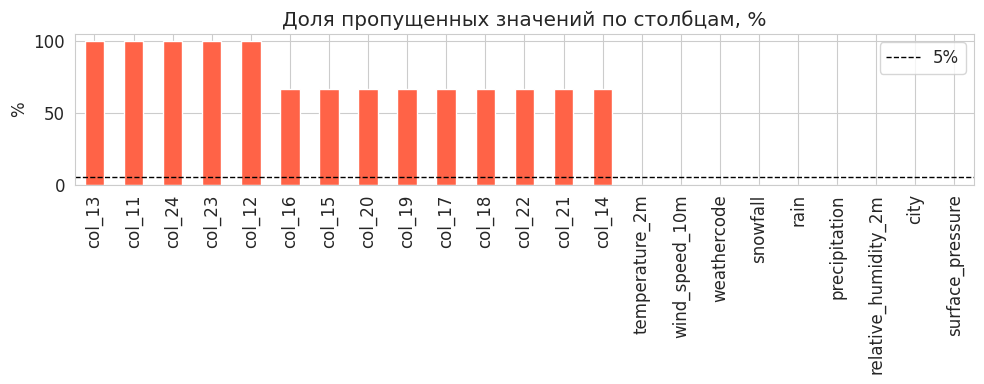

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
miss = all_cities.isna().mean().sort_values(ascending=False) * 100
miss.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Доля пропущенных значений по столбцам, %')
ax.set_ylabel('%')
ax.axhline(5, color='k', linestyle='--', linewidth=1, label='5%')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Анализ временного ряда

### 4.1 Визуализация

Города в датасете: ['Геленджик' 'Санкт-Петербург' 'Москва']


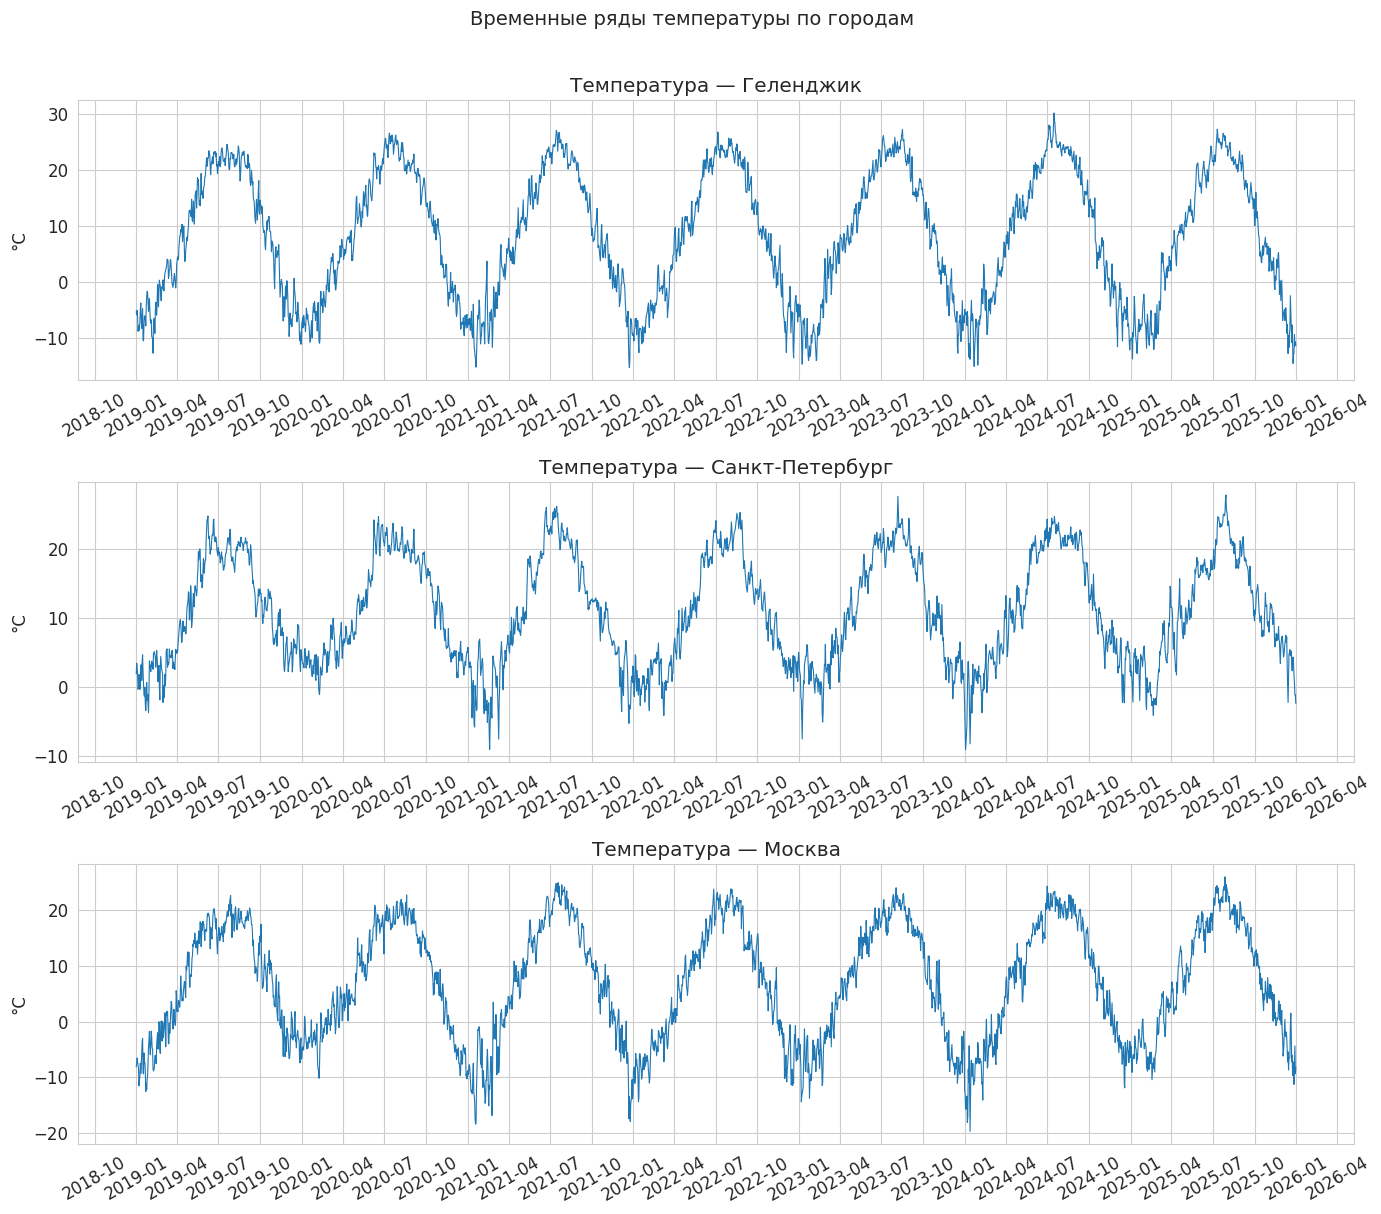

In [13]:
cities = all_cities[CITY_COL].unique()
print('Города в датасете:', cities)

fig, axes = plt.subplots(len(cities), 1, figsize=(14, 4 * len(cities)), sharex=False)
if len(cities) == 1:
    axes = [axes]

for ax, city in zip(axes, cities):
    sub = all_cities[all_cities[CITY_COL] == city][TARGET_COL]
    ax.plot(sub, linewidth=0.8)
    ax.set_title(f'Температура — {city}')
    ax.set_ylabel('°C')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    plt.setp(ax.get_xticklabels(), rotation=30)

plt.suptitle('Временные ряды температуры по городам', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 4.2 Проверка стационарности — тест Дики-Фуллера (ADF)

Нулевая гипотеза H0: ряд нестационарен (есть единичный корень).  
Если p-value < 0.05 — отвергаем H0, ряд стационарен.

In [14]:
try:
    from statsmodels.tsa.stattools import adfuller, kpss
    STATSMODELS = True
except ImportError:
    STATSMODELS = False
    print('statsmodels не установлен. ADF-тест пропускается.')
    print('Установите: pip install statsmodels')

if STATSMODELS:
    for city in cities:
        series = all_cities[all_cities[CITY_COL] == city][TARGET_COL].dropna()

        adf_res = adfuller(series, autolag='AIC')
        kpss_res = kpss(series, regression='ct', nlags='auto')

        print(f'\n=== {city} ===')
        print(f'  ADF statistic: {adf_res[0]:.4f},  p-value: {adf_res[1]:.4f}  '
              f'--> {"Стационарен" if adf_res[1] < 0.05 else "НЕ стационарен"}')
        print(f'  KPSS statistic: {kpss_res[0]:.4f},  p-value: {kpss_res[1]:.4f}  '
              f'--> {"Стационарен" if kpss_res[1] > 0.05 else "НЕ стационарен"}')


=== Геленджик ===
  ADF statistic: -3.4220,  p-value: 0.0102  --> Стационарен
  KPSS statistic: 0.0444,  p-value: 0.1000  --> Стационарен

=== Санкт-Петербург ===
  ADF statistic: -2.5627,  p-value: 0.1010  --> НЕ стационарен
  KPSS statistic: 0.0479,  p-value: 0.1000  --> Стационарен

=== Москва ===
  ADF statistic: -3.2259,  p-value: 0.0185  --> Стационарен
  KPSS statistic: 0.0487,  p-value: 0.1000  --> Стационарен


/tmp/ipykernel_15796/3387947796.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression='ct', nlags='auto')
/tmp/ipykernel_15796/3387947796.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression='ct', nlags='auto')
/tmp/ipykernel_15796/3387947796.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series, regression='ct', nlags='auto')


### 4.3 Декомпозиция на тренд, сезонность и остатки

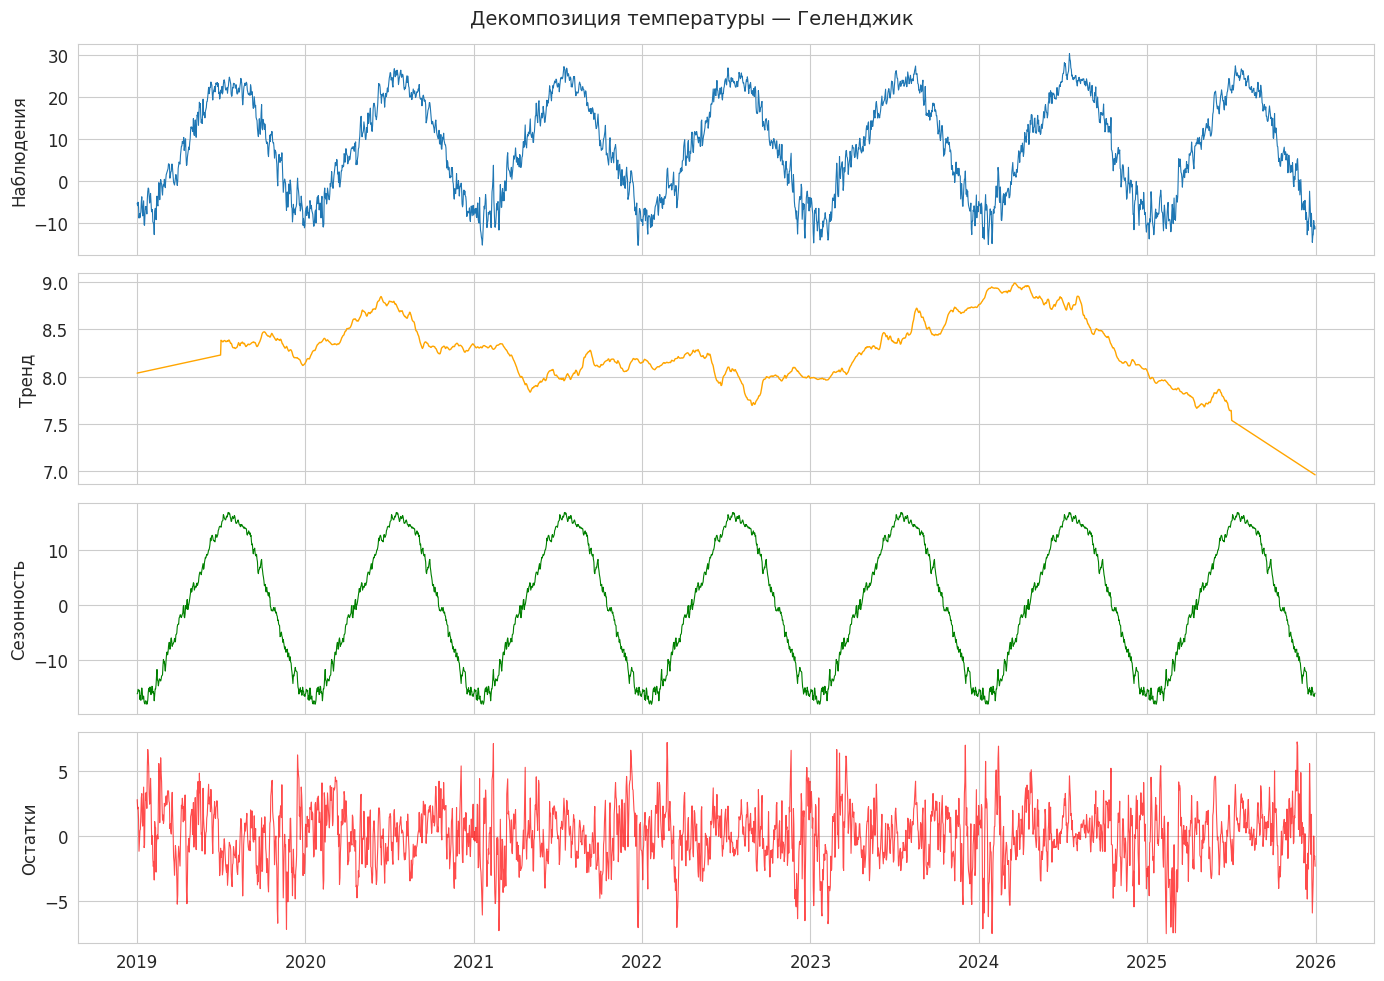

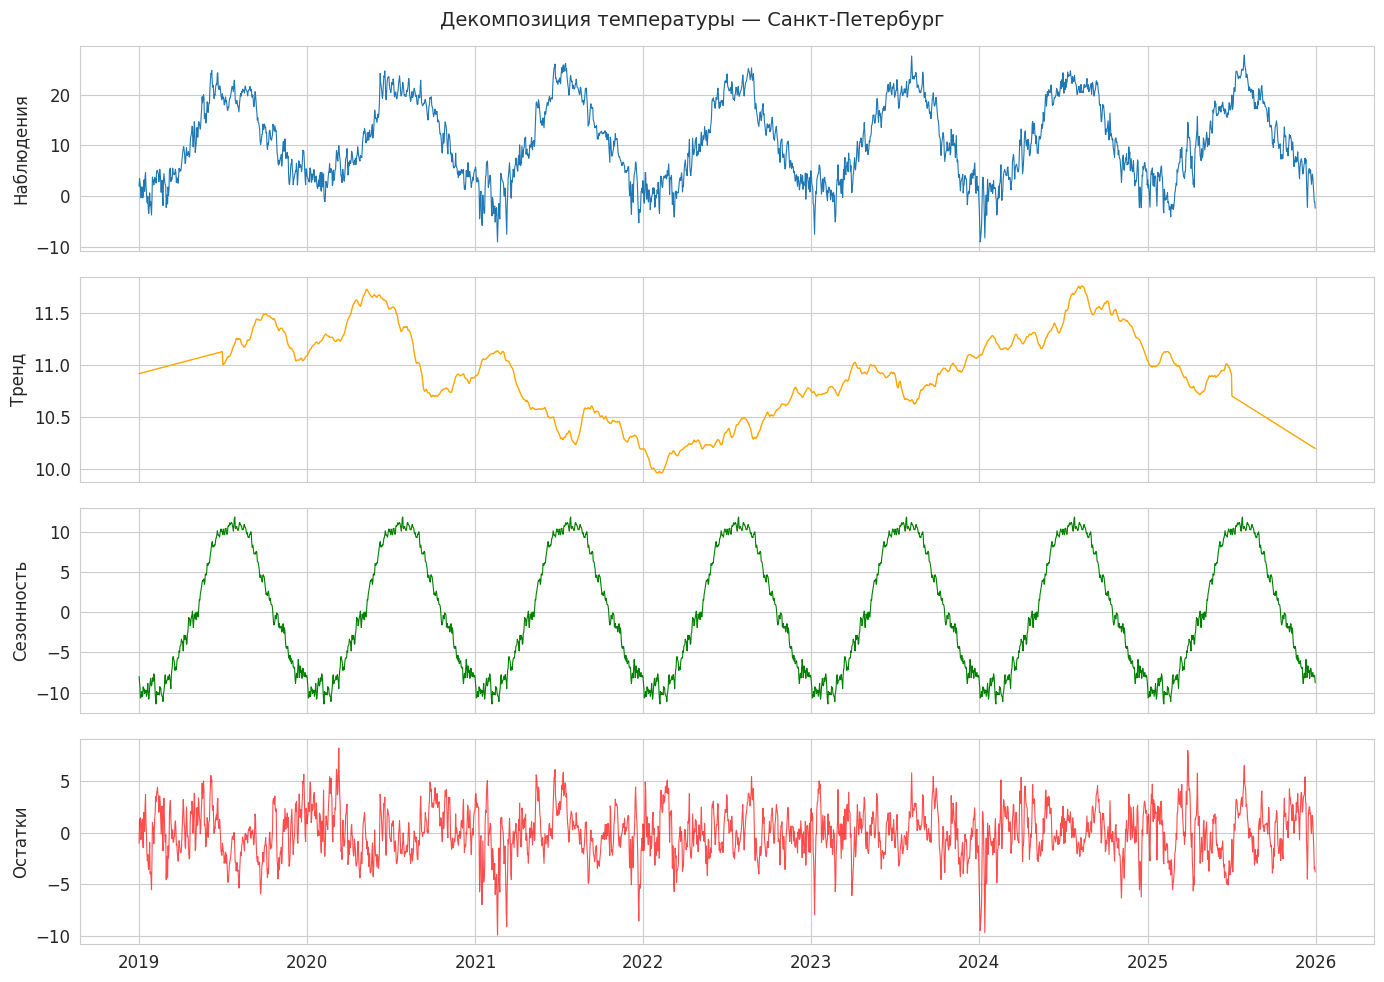

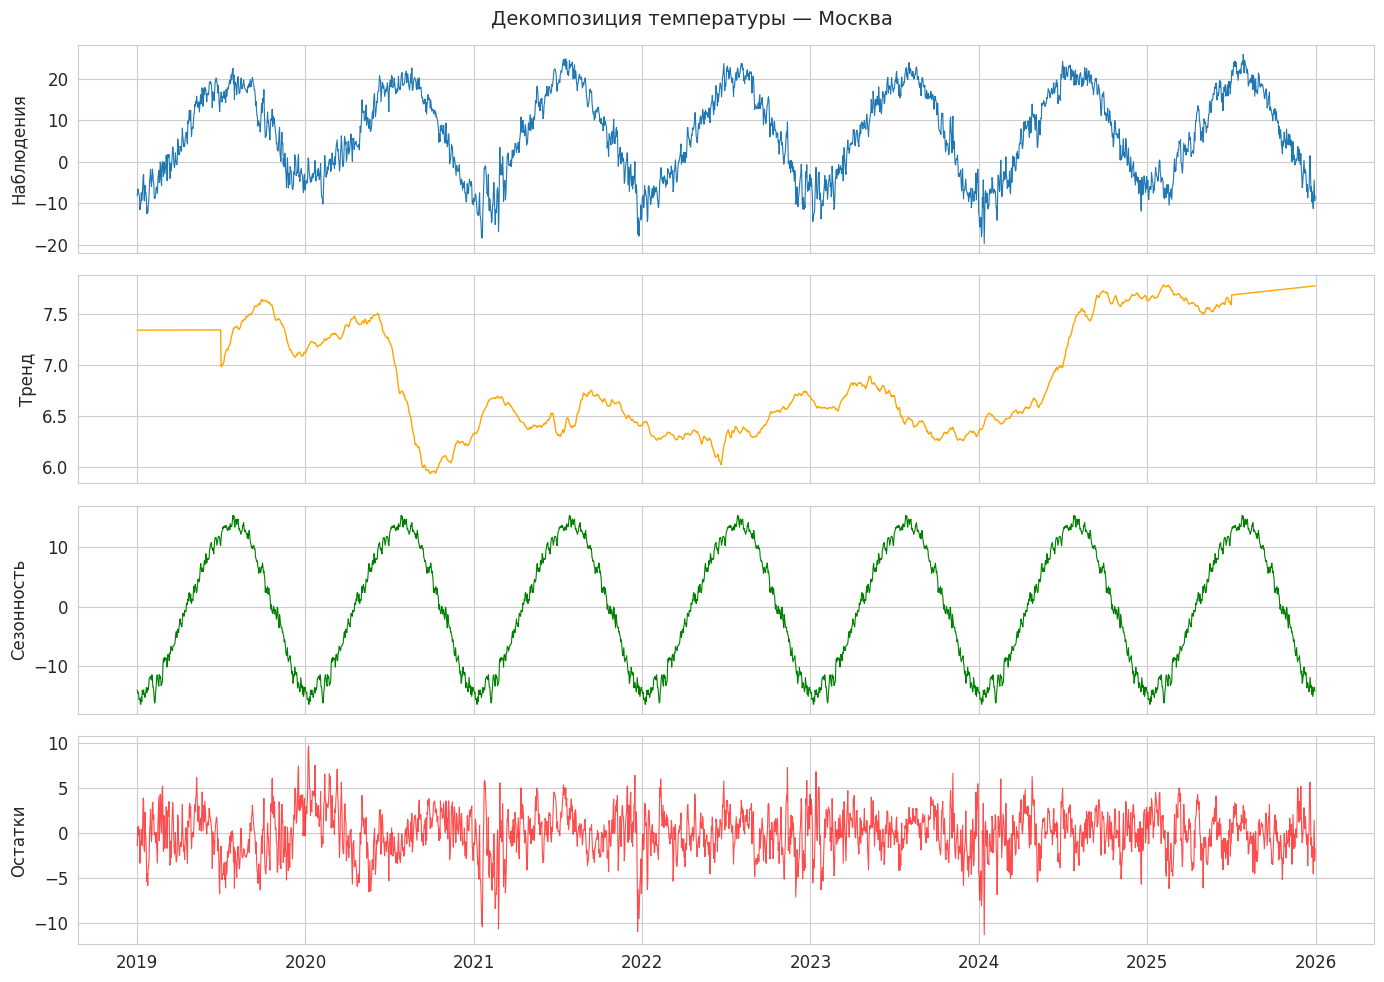

In [15]:
if STATSMODELS:
    from statsmodels.tsa.seasonal import seasonal_decompose

    for city in cities:
        series = all_cities[all_cities[CITY_COL] == city][TARGET_COL].dropna()
        series = series.asfreq('D').interpolate()

        period = 365 if len(series) > 730 else 7
        decomp = seasonal_decompose(series, model='additive', period=period, extrapolate_trend='freq')

        fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
        axes[0].plot(decomp.observed, linewidth=0.8); axes[0].set_ylabel('Наблюдения')
        axes[1].plot(decomp.trend, color='orange', linewidth=1); axes[1].set_ylabel('Тренд')
        axes[2].plot(decomp.seasonal, color='green', linewidth=0.8); axes[2].set_ylabel('Сезонность')
        axes[3].plot(decomp.resid, color='red', linewidth=0.8, alpha=0.7); axes[3].set_ylabel('Остатки')
        fig.suptitle(f'Декомпозиция температуры — {city}', fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    for city in cities:
        series = all_cities[all_cities[CITY_COL] == city][TARGET_COL].dropna()

        fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
        axes[0].plot(series, linewidth=0.8, label='Наблюдения')
        axes[0].plot(series.rolling(30).mean(), color='orange', linewidth=2, label='MA-30')
        axes[0].set_ylabel('Температура')
        axes[0].legend()

        diff = series.diff()
        axes[1].plot(diff, color='green', linewidth=0.6)
        axes[1].set_ylabel('Первые разности')

        rolling_std = series.rolling(30).std()
        axes[2].plot(rolling_std, color='red', linewidth=0.8)
        axes[2].set_ylabel('Скользящее std (30 дней)')

        fig.suptitle(f'Анализ тренда и изменчивости — {city}', fontsize=14)
        plt.tight_layout()
        plt.show()

### 4.4 Спектральный анализ (FFT / Periodogram)

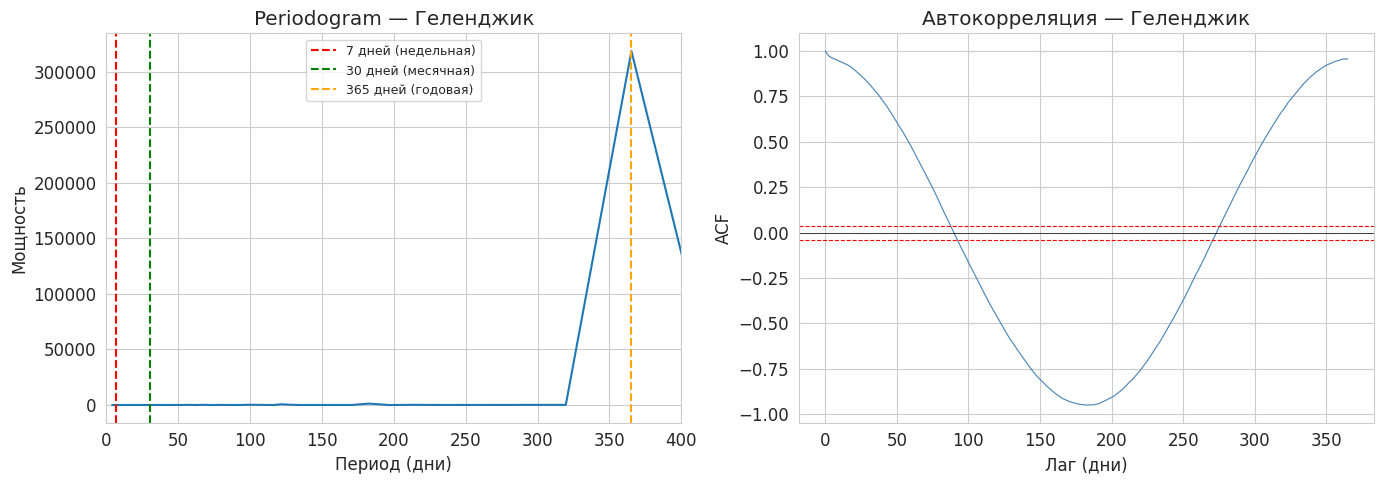

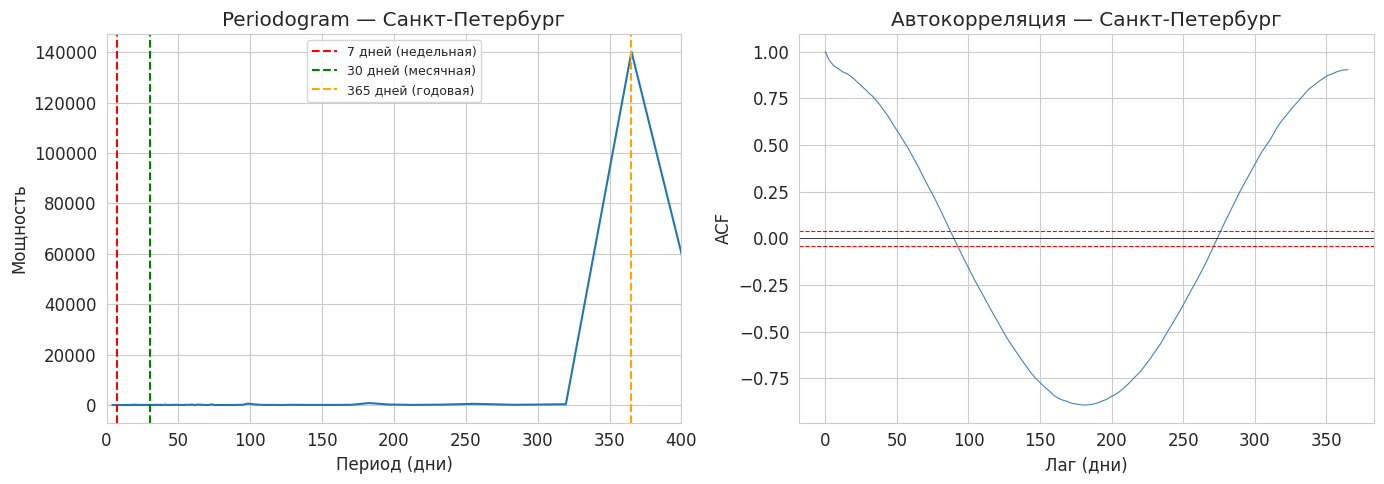

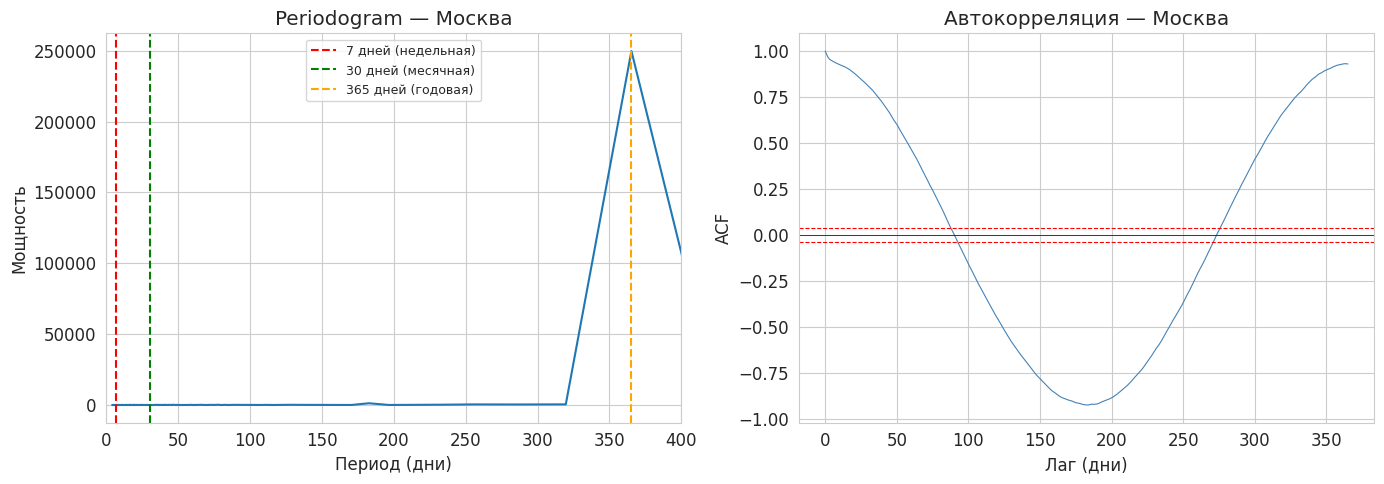

In [16]:
for city in cities:
    series = all_cities[all_cities[CITY_COL] == city][TARGET_COL].dropna()

    series_filled = series.asfreq('D').interpolate()
    vals = series_filled.values
    vals = vals - vals.mean()

    freqs, power = periodogram(vals, fs=1.0)
    periods = 1 / (freqs[1:] + 1e-10)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(periods[:len(periods)//2], power[1:len(periods)//2+1])
    axes[0].set_xlim([0, 400])
    axes[0].axvline(7, color='r', linestyle='--', label='7 дней (недельная)')
    axes[0].axvline(30, color='g', linestyle='--', label='30 дней (месячная)')
    axes[0].axvline(365, color='orange', linestyle='--', label='365 дней (годовая)')
    axes[0].set_xlabel('Период (дни)')
    axes[0].set_ylabel('Мощность')
    axes[0].set_title(f'Periodogram — {city}')
    axes[0].legend(fontsize=9)

    n_lags = min(365, len(vals) // 3)
    acf_vals = [np.corrcoef(vals[:-lag], vals[lag:])[0, 1] if lag > 0 else 1.0
                for lag in range(n_lags + 1)]

    axes[1].plot(range(n_lags + 1), acf_vals, color='steelblue', linewidth=0.8)
    conf = 1.96 / np.sqrt(len(vals))
    axes[1].axhline(conf, color='r', linestyle='--', linewidth=0.8)
    axes[1].axhline(-conf, color='r', linestyle='--', linewidth=0.8)
    axes[1].axhline(0, color='k', linewidth=0.5)
    axes[1].set_xlabel('Лаг (дни)')
    axes[1].set_ylabel('ACF')
    axes[1].set_title(f'Автокорреляция — {city}')

    plt.tight_layout()
    plt.show()

## 5. Feature Engineering

Формируем признаки для каждого города:
- **Лаговые признаки** — значения температуры за предшествующие `WINDOW` дней
- **Скользящая статистика** — среднее, std, min, max за разные окна
- **Календарные признаки** — день года, номер недели, месяц (синус/косинус для цикличности)
- **Признаки других переменных** — влажность, давление и т.д. (если есть)
- **Разности** — первые разности для передачи тренда

In [17]:
def make_features(df, target_col, window, horizon):
    feat_rows = []
    target_rows = []
    dates = []

    vals = df[target_col].values
    idx = df.index

    for i in range(window, len(vals) - horizon + 1):
        window_vals = vals[i - window: i]
        target_vals = vals[i: i + horizon]

        row = {}

        for lag in range(1, window + 1):
            row[f'lag_{lag}'] = vals[i - lag]

        for w in [7, 14, 30]:
            if w <= window:
                sub = vals[i - w: i]
                row[f'roll_mean_{w}'] = np.mean(sub)
                row[f'roll_std_{w}'] = np.std(sub)
                row[f'roll_min_{w}'] = np.min(sub)
                row[f'roll_max_{w}'] = np.max(sub)

        row['diff_1'] = vals[i - 1] - vals[i - 2] if i >= 2 else 0
        row['diff_7'] = vals[i - 1] - vals[i - 8] if i >= 8 else 0

        dt = idx[i]
        doy = dt.day_of_year
        row['sin_doy'] = np.sin(2 * np.pi * doy / 365.25)
        row['cos_doy'] = np.cos(2 * np.pi * doy / 365.25)
        row['sin_week'] = np.sin(2 * np.pi * dt.week / 52)
        row['cos_week'] = np.cos(2 * np.pi * dt.week / 52)
        row['month'] = dt.month
        row['weekday'] = dt.weekday()

        extra_cols = [c for c in df.columns
              if c not in [target_col, CITY_COL]
              and not df[c].isna().all()
              and not c.startswith('col_')]

        for col in extra_cols:
            row[f'{col}_lag1'] = df[col].iloc[i - 1] if i - 1 < len(df) else np.nan
            row[f'{col}_roll7'] = df[col].iloc[i - 7:i].mean() if i >= 7 else np.nan

        feat_rows.append(row)
        target_rows.append(target_vals)
        dates.append(dt)

    X = pd.DataFrame(feat_rows, index=dates)
    Y = pd.DataFrame(target_rows, index=dates,
                     columns=[f'h_{h+1}' for h in range(horizon)])
    return X, Y


print(f'Параметры: окно = {WINDOW} дней, горизонт = {HORIZON} дней')

city_datasets = {}
for city in cities:
    sub = all_cities[all_cities[CITY_COL] == city].drop(columns=[CITY_COL])
    sub = sub.asfreq('D').interpolate()

    X, Y = make_features(sub, TARGET_COL, WINDOW, HORIZON)
    X = X.fillna(method='bfill').fillna(method='ffill')
    city_datasets[city] = (X, Y)
    print(f'{city}: X={X.shape}, Y={Y.shape}')
    display(X.head(3))

Параметры: окно = 21 дней, горизонт = 7 дней
Геленджик: X=(2530, 51), Y=(2530, 7)


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,rain_lag1,rain_roll7,snowfall_lag1,snowfall_roll7,weathercode_lag1,weathercode_roll7,wind_speed_10m_lag1,wind_speed_10m_roll7,surface_pressure_lag1,surface_pressure_roll7
2019-01-22,-6.089583,-6.566667,-5.989583,-7.732609,-10.462745,-10.312500,-4.663043,-6.468085,-8.225490,-6.463830,...,0.0,0.0,0.0,0.0,0.625000,1.483039,14.006250,13.554224,1006.291668,1008.077118
2019-01-23,-7.773469,-6.089583,-6.566667,-5.989583,-7.732609,-10.462745,-10.312500,-4.663043,-6.468085,-8.225490,...,0.0,0.0,0.0,0.0,3.000000,1.669547,10.244898,12.860334,1005.887997,1008.542963
2019-01-24,-4.271429,-7.773469,-6.089583,-6.566667,-5.989583,-7.732609,-10.462745,-10.312500,-4.663043,-6.468085,...,0.0,0.0,0.0,0.0,1.795918,1.609505,15.143750,12.964798,1008.430606,1009.464895


Санкт-Петербург: X=(2530, 51), Y=(2530, 7)


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,rain_lag1,rain_roll7,snowfall_lag1,snowfall_roll7,weathercode_lag1,weathercode_roll7,wind_speed_10m_lag1,wind_speed_10m_roll7,surface_pressure_lag1,surface_pressure_roll7
2019-01-22,-2.533333,-0.020833,-1.369565,-1.016667,0.397872,2.120833,4.658333,3.763043,0.950000,3.212766,...,0.0,0.0,0.0,0.0,1.522727,2.319254,14.104167,14.775903,1014.791663,1005.259575
2019-01-23,-3.404167,-2.533333,-0.020833,-1.369565,-1.016667,0.397872,2.120833,4.658333,3.763043,0.950000,...,0.0,0.0,0.0,0.0,2.645161,2.277779,13.082979,14.144007,1017.233334,1008.677380
2019-01-24,-2.054348,-3.404167,-2.533333,-0.020833,-1.369565,-1.016667,0.397872,2.120833,4.658333,3.763043,...,0.0,0.0,0.0,0.0,2.511628,2.208011,14.638298,13.602366,1014.727084,1011.249404


Москва: X=(2530, 51), Y=(2530, 7)


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,rain_lag1,rain_roll7,snowfall_lag1,snowfall_roll7,weathercode_lag1,weathercode_roll7,wind_speed_10m_lag1,wind_speed_10m_roll7,surface_pressure_lag1,surface_pressure_roll7
2019-01-22,-8.895745,-7.351064,-7.487234,-5.620833,-9.391950,-9.139348,-3.041667,-3.529787,-5.718750,-8.137500,...,0.0,0.0,0.0,0.0,1.282609,1.492645,13.337500,17.345808,996.766668,995.534210
2019-01-23,-12.512500,-8.895745,-7.351064,-7.487234,-5.620833,-9.391950,-9.139348,-3.041667,-3.529787,-5.718750,...,0.0,0.0,0.0,0.0,1.291667,1.359709,11.283333,16.296701,1000.277088,997.192246
2019-01-24,-11.068750,-12.512500,-8.895745,-7.351064,-7.487234,-5.620833,-9.391950,-9.139348,-3.041667,-3.529787,...,0.0,0.0,0.0,0.0,1.595745,1.346601,11.743750,16.094440,1002.342103,998.391708


### 5.1 Важность признаков (предварительная оценка)

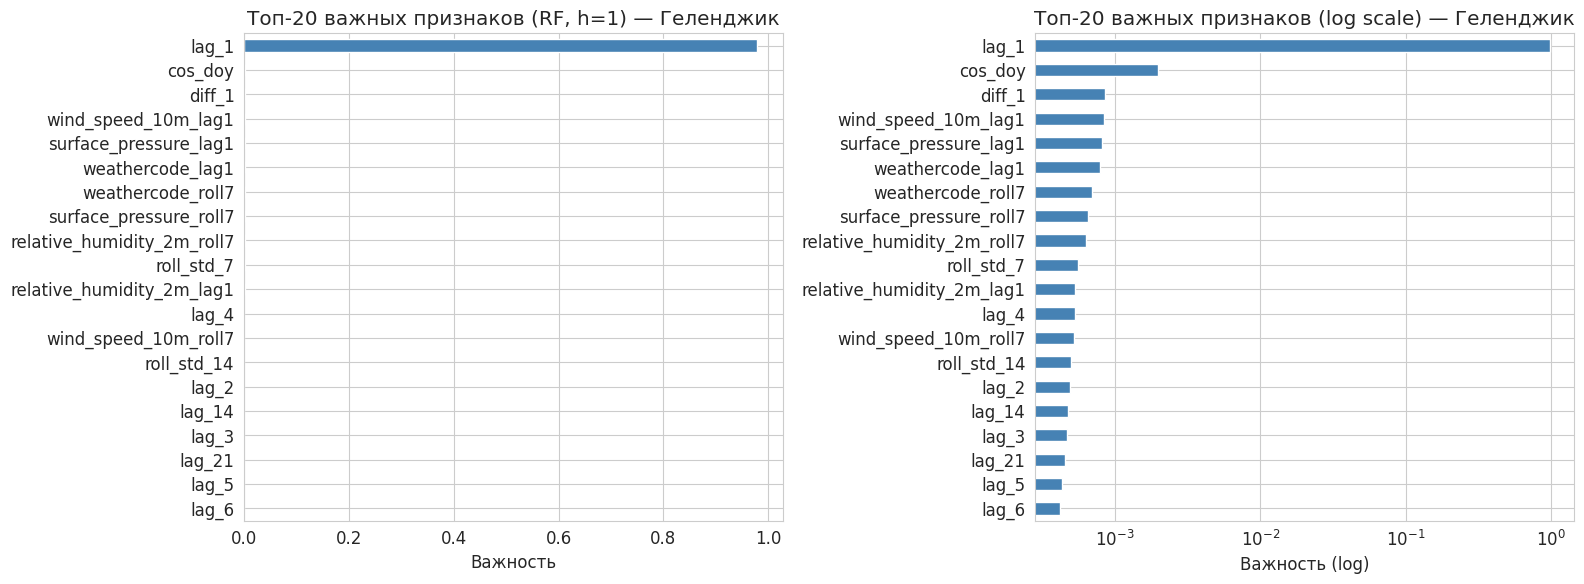

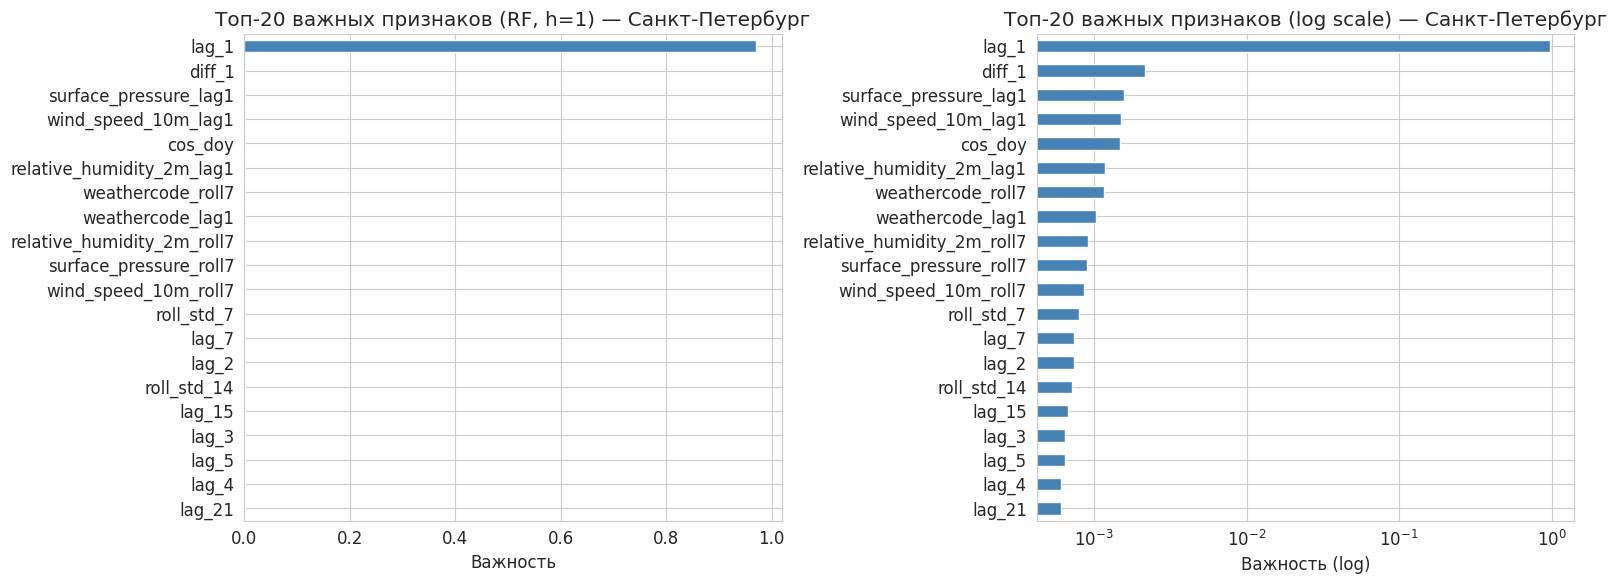

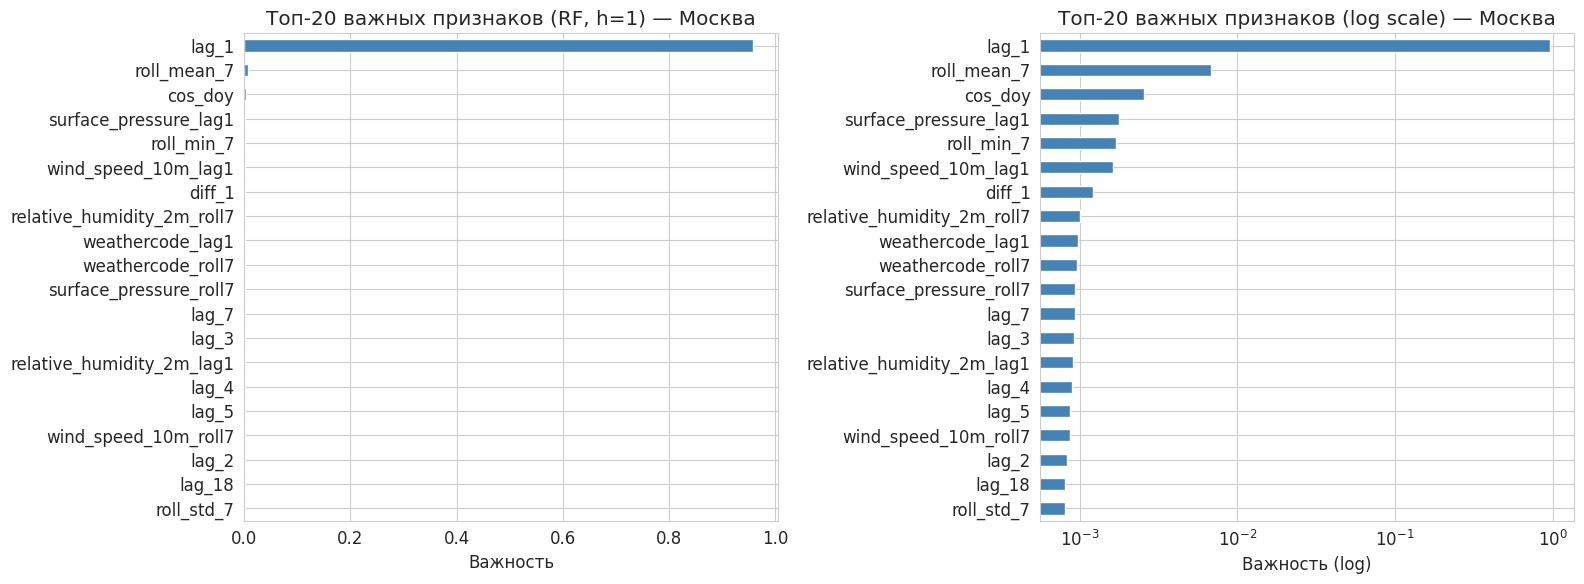

In [18]:
for city in cities:
    X_all, Y_all = city_datasets[city]

    median_vals = X_all.median()
    X_clean = X_all.fillna(median_vals)
    X_clean = X_clean[X_clean.columns[X_clean.notna().any()]]

    rf_quick = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf_quick.fit(X_clean, Y_all['h_1'])

    importances = pd.Series(rf_quick.feature_importances_, index=X_clean.columns)
    top20 = importances.sort_values(ascending=False).head(20)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    top20.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title(f'Топ-20 важных признаков (RF, h=1) — {city}')
    axes[0].set_xlabel('Важность')
    axes[0].invert_yaxis()

    top20.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_xscale('log')
    axes[1].set_title(f'Топ-20 важных признаков (log scale) — {city}')
    axes[1].set_xlabel('Важность (log)')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

## 6. Разбивка на Train / Validation / Test

Используем **хронологическое** разделение:  
- Train: первые 70%  
- Validation: следующие 15%  
- Test: последние 15%

In [20]:
def chrono_split(X, Y, train_frac=0.70, val_frac=0.15):
    n = len(X)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    X_train, Y_train = X.iloc[:n_train], Y.iloc[:n_train]
    X_val,   Y_val   = X.iloc[n_train: n_train + n_val], Y.iloc[n_train: n_train + n_val]
    X_test,  Y_test  = X.iloc[n_train + n_val:], Y.iloc[n_train + n_val:]

    return (X_train, Y_train), (X_val, Y_val), (X_test, Y_test)


splits = {}
for city in cities:
    X, Y = city_datasets[city]
    train, val, test = chrono_split(X, Y)
    splits[city] = (train, val, test)
    print(f'{city}: train={train[0].shape[0]}, val={val[0].shape[0]}, test={test[0].shape[0]}')
    print(f'  Train: {train[0].index[0].date()} – {train[0].index[-1].date()}')
    print(f'  Val:   {val[0].index[0].date()}   – {val[0].index[-1].date()}')
    print(f'  Test:  {test[0].index[0].date()}  – {test[0].index[-1].date()}')

Геленджик: train=1771, val=379, test=380
  Train: 2019-01-22 – 2023-11-27
  Val:   2023-11-28   – 2024-12-10
  Test:  2024-12-11  – 2025-12-25
Санкт-Петербург: train=1771, val=379, test=380
  Train: 2019-01-22 – 2023-11-27
  Val:   2023-11-28   – 2024-12-10
  Test:  2024-12-11  – 2025-12-25
Москва: train=1771, val=379, test=380
  Train: 2019-01-22 – 2023-11-27
  Val:   2023-11-28   – 2024-12-10
  Test:  2024-12-11  – 2025-12-25


## 7. Метрики качества прогноза

In [21]:
def wape(y_true, y_pred):
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-10) * 100


def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    mask = np.abs(y_true) > 0.1
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def directional_accuracy(y_true, y_pred, y_base):
    y_true, y_pred, y_base = map(np.array, [y_true, y_pred, y_base])
    y_true, y_pred = y_true.ravel(), y_pred.ravel()
    y_base = np.repeat(y_base.ravel(), y_true.shape[0] // y_base.shape[0] + 1)[:y_true.shape[0]]
    dir_true = np.sign(y_true - y_base)
    dir_pred = np.sign(y_pred - y_base)
    return np.mean(dir_true == dir_pred) * 100


def directional_r2(y_true, y_pred, y_base):
    y_true, y_pred, y_base = map(np.array, [y_true, y_pred, y_base])
    y_true, y_pred = y_true.ravel(), y_pred.ravel()
    y_base = np.repeat(y_base.ravel(), y_true.shape[0] // y_base.shape[0] + 1)[:y_true.shape[0]]
    dir_true = np.sign(y_true - y_base)
    dir_pred = np.sign(y_pred - y_base)
    # Наивная модель: всегда предсказывает 0 (нет изменений)
    dir_naive = np.zeros_like(dir_true)
    acc_model = np.mean(dir_true == dir_pred)
    acc_naive = np.mean(dir_true == dir_naive)
    return 1 - (1 - acc_model) / (1 - acc_naive + 1e-10)


def evaluate_all(y_true, y_pred, y_base, prefix=''):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return {
        f'{prefix}MAE':    mean_absolute_error(y_true.ravel(), y_pred.ravel()),
        f'{prefix}WAPE':   wape(y_true, y_pred),
        f'{prefix}MAPE':   mape(y_true, y_pred),
        f'{prefix}DA':     directional_accuracy(y_true, y_pred, y_base),
        f'{prefix}Dir_R2': directional_r2(y_true, y_pred, y_base),
    }

print('Функции метрик определены.')

Функции метрик определены.


## 8. Стратегия 1: Рекурсивный прогноз (Recursive)

Одна модель обучается предсказывать **один шаг вперёд (h=1)**.  
Для получения прогноза на `h` шагов вперёд модель применяется итеративно:
на каждом шаге предыдущий прогноз добавляется в окно признаков.

In [22]:
def recursive_predict(model, X_test, horizon, window, lag_cols):
    preds_all = []
    for i in range(len(X_test)):
        row = X_test.iloc[i].copy()
        preds_horizon = []
        for h in range(horizon):
            pred = model.predict(row.values.reshape(1, -1))[0]
            preds_horizon.append(pred)
            # Сдвигаем лаги
            for lag in range(min(window - 1, len(lag_cols) - 1), 0, -1):
                row[lag_cols[lag]] = row[lag_cols[lag - 1]]
            if lag_cols:
                row[lag_cols[0]] = pred
            # Обновляем скользящие признаки (приближённо)
        preds_all.append(preds_horizon)
    return np.array(preds_all)


print('Функция рекурсивного прогноза определена.')

Функция рекурсивного прогноза определена.


## 9. Стратегия 2: Direct / MIMO — модель на каждый горизонт

Для каждого шага `h` от 1 до `HORIZON` обучается **отдельная модель**.  
Нет накопления ошибок, но требует `HORIZON` раз больше моделей.

## 10. Подбор гиперпараметров через Optuna и обучение моделей

In [23]:
def get_best_params_optuna(X_train, y_train, X_val, y_val, model_type, n_trials=50):
    if not OPTUNA_AVAILABLE:
        defaults = {
            'dt':  {'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 5},
            'rf':  {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 5,
                    'min_samples_leaf': 3, 'max_features': 'sqrt'},
            'gb':  {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05,
                    'subsample': 0.8, 'min_samples_split': 5},
        }
        return defaults.get(model_type, {})

    _median = X_train.median()
    X_tr = X_train.fillna(_median)
    X_va = X_val.fillna(_median)

    def objective(trial):
        if model_type == 'dt':
            params = {
                'max_depth':         trial.suggest_int('max_depth', 2, 12),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
            }
            model = DecisionTreeRegressor(**params, random_state=RANDOM_STATE)
        elif model_type == 'rf':
            params = {
                'n_estimators':      trial.suggest_int('n_estimators', 50, 400),
                'max_depth':         trial.suggest_int('max_depth', 3, 15),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features':      trial.suggest_categorical('max_features',
                                         ['sqrt', 'log2', 0.5, 0.7]),
            }
            model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        elif model_type == 'gb':
            params = {
                'n_estimators':    trial.suggest_int('n_estimators', 50, 500),
                'max_depth':       trial.suggest_int('max_depth', 2, 8),
                'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
                'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            }
            model = GradientBoostingRegressor(**params, random_state=RANDOM_STATE)
        else:
            return float('inf')

        model.fit(X_tr, y_train)
        preds = model.predict(X_va)
        return mean_absolute_error(y_val, preds)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def build_model(model_type, params):
    if model_type == 'dt':
        return DecisionTreeRegressor(**params, random_state=RANDOM_STATE)
    elif model_type == 'rf':
        return RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    elif model_type == 'gb':
        return GradientBoostingRegressor(**params, random_state=RANDOM_STATE)
    else:
        raise ValueError(f'Неизвестный тип модели: {model_type}')


print('Функции подбора параметров и создания моделей определены.')


Функции подбора параметров и создания моделей определены.


In [26]:
N_TRIALS = 15
N_TRIALS_DIRECT = 5
MODEL_TYPES = ['dt', 'rf', 'gb']
MODEL_NAMES = {'dt': 'Decision Tree', 'rf': 'Random Forest', 'gb': 'Gradient Boosting'}

results = {}  # {city: {model_type: {strategy: metrics}}}

for city in cities:
    (X_train, Y_train), (X_val, Y_val), (X_test, Y_test) = splits[city]
    median_vals = X_train.median()
    X_train = X_train.fillna(median_vals)
    X_val   = X_val.fillna(median_vals)
    X_tv    = pd.concat([X_train, X_val])

    print(f'{city}:')
    print(f'  X_train NaN: {X_train.isna().sum().sum()}')
    print(f'  X_val   NaN: {X_val.isna().sum().sum()}')
    print(f'  X_tv    NaN: {X_tv.isna().sum().sum()}')
    if X_tv.isna().sum().sum() > 0:
        cols = X_tv.columns[X_tv.isna().any()].tolist()
        print(f'  Колонки с NaN: {cols}')
        for c in cols:
            print(f'    {c}: train={X_train[c].isna().sum()}, val={X_val[c].isna().sum()}, tv={X_tv[c].isna().sum()}')

for city in cities:
    print(f'\n{"="*60}')
    print(f'ГОРОД: {city}')
    print(f'{"="*60}')

    (X_train, Y_train), (X_val, Y_val), (X_test, Y_test) = splits[city]

    median_vals = X_train.median()
    X_train = X_train.fillna(median_vals)
    X_val   = X_val.fillna(median_vals)
    X_test  = X_test.fillna(median_vals)

    valid_cols = X_train.columns[X_train.notna().any()].tolist()
    X_train = X_train[valid_cols]
    X_val   = X_val[valid_cols]
    X_test  = X_test[valid_cols]

    X_tv = pd.concat([X_train, X_val])
    Y_tv = pd.concat([Y_train, Y_val])

    lag_cols = [c for c in X_train.columns if c.startswith('lag_')]
    results[city] = {}

    for mtype in MODEL_TYPES:
        print(f'\n  --- {MODEL_NAMES[mtype]} ---')
        results[city][mtype] = {}

        print('    [Recursive] Подбор гиперпараметров...')
        best_params = get_best_params_optuna(
            X_train, Y_train['h_1'],
            X_val,   Y_val['h_1'],
            mtype, n_trials=N_TRIALS
        )
        print(f'    Лучшие параметры: {best_params}')

        model_rec = build_model(mtype, best_params)
        model_rec.fit(X_tv, Y_tv['h_1'])

        preds_rec = recursive_predict(model_rec, X_test, HORIZON, WINDOW, lag_cols)
        y_base = X_test['lag_1'].values

        metrics_rec = evaluate_all(Y_test.values, preds_rec, y_base, prefix='')
        results[city][mtype]['recursive'] = metrics_rec
        print('    [Recursive] Метрики на тесте:')
        for k, v in metrics_rec.items():
            print(f'      {k}: {v:.3f}')

        print('    [Direct] Обучение...')
        direct_models = []
        for h in range(HORIZON):
            best_params_h = get_best_params_optuna(
                X_train, Y_train[f'h_{h+1}'],
                X_val,   Y_val[f'h_{h+1}'],
                mtype, n_trials=N_TRIALS_DIRECT
            )
            m = build_model(mtype, best_params_h)
            m.fit(X_tv, Y_tv[f'h_{h+1}'])
            direct_models.append(m)

        preds_direct = np.column_stack(
            [m.predict(X_test) for m in direct_models]
        )

        metrics_dir = evaluate_all(Y_test.values, preds_direct, y_base, prefix='')
        results[city][mtype]['direct'] = metrics_dir
        print('    [Direct] Метрики на тесте:')
        for k, v in metrics_dir.items():
            print(f'      {k}: {v:.3f}')

        results[city][mtype]['preds_rec'] = preds_rec
        results[city][mtype]['preds_dir'] = preds_direct
        results[city][mtype]['Y_test'] = Y_test
        results[city][mtype]['y_base'] = y_base


Геленджик:
  X_train NaN: 0
  X_val   NaN: 0
  X_tv    NaN: 0
Санкт-Петербург:
  X_train NaN: 0
  X_val   NaN: 0
  X_tv    NaN: 0
Москва:
  X_train NaN: 0
  X_val   NaN: 0
  X_tv    NaN: 0

ГОРОД: Геленджик

  --- Decision Tree ---
    [Recursive] Подбор гиперпараметров...
    Лучшие параметры: {'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 6}
    [Recursive] Метрики на тесте:
      MAE: 2.195
      WAPE: 18.632
      MAPE: 51.054
      DA: 90.376
      Dir_R2: 0.904
    [Direct] Обучение...
    [Direct] Метрики на тесте:
      MAE: 2.045
      WAPE: 17.356
      MAPE: 43.291
      DA: 91.805
      Dir_R2: 0.918

  --- Random Forest ---
    [Recursive] Подбор гиперпараметров...
    Лучшие параметры: {'n_estimators': 307, 'max_depth': 15, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 0.7}
    [Recursive] Метрики на тесте:
      MAE: 1.958
      WAPE: 16.617
      MAPE: 38.058
      DA: 92.143
      Dir_R2: 0.921
    [Direct] Обучение...
    [Direct] Метри

## 11. Сравнение результатов

In [27]:
rows = []
for city in cities:
    for mtype in MODEL_TYPES:
        for strategy in ['recursive', 'direct']:
            if strategy in results[city][mtype]:
                m = results[city][mtype][strategy]
                rows.append({
                    'Город':    city,
                    'Модель':   MODEL_NAMES[mtype],
                    'Стратегия': strategy.capitalize(),
                    'MAE':      round(m['MAE'], 3),
                    'WAPE':     round(m['WAPE'], 2),
                    'MAPE':     round(m['MAPE'], 2),
                    'DA (%)':   round(m['DA'], 1),
                    'Dir R²':   round(m['Dir_R2'], 3),
                })

summary = pd.DataFrame(rows)
print('Сводная таблица метрик:')
display(summary.sort_values(['Город', 'MAE']))

Сводная таблица метрик:


,Город,Модель,Стратегия,MAE,WAPE,MAPE,DA (%),Dir R²
3,Геленджик,Random Forest,Direct,1.844,15.65,36.33,92.5,0.925
5,Геленджик,Gradient Boosting,Direct,1.877,15.93,36.83,92.0,0.920
2,Геленджик,Random Forest,Recursive,1.958,16.62,38.06,92.1,0.921
4,Геленджик,Gradient Boosting,Recursive,2.028,17.21,41.46,91.5,0.915
1,Геленджик,Decision Tree,Direct,2.045,17.36,43.29,91.8,0.918
0,Геленджик,Decision Tree,Recursive,2.195,18.63,51.05,90.4,0.904
17,Москва,Gradient Boosting,Direct,1.947,19.20,60.06,88.6,0.886
15,Москва,Random Forest,Direct,2.010,19.82,63.45,87.8,0.878
14,Москва,Random Forest,Recursive,2.046,20.18,61.02,88.8,0.888
16,Москва,Gradient Boosting,Recursive,2.118,20.89,61.23,87.9,0.879


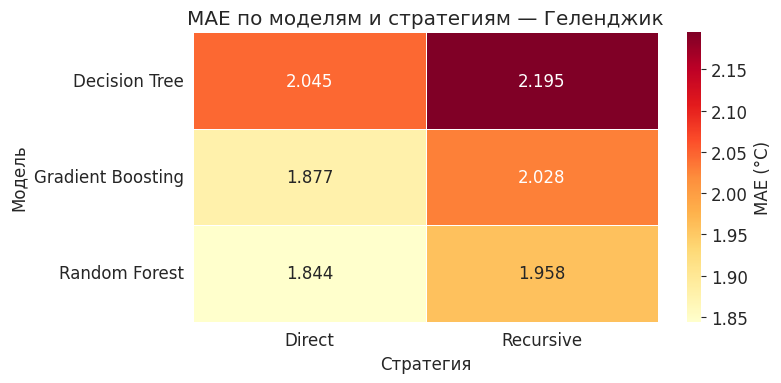

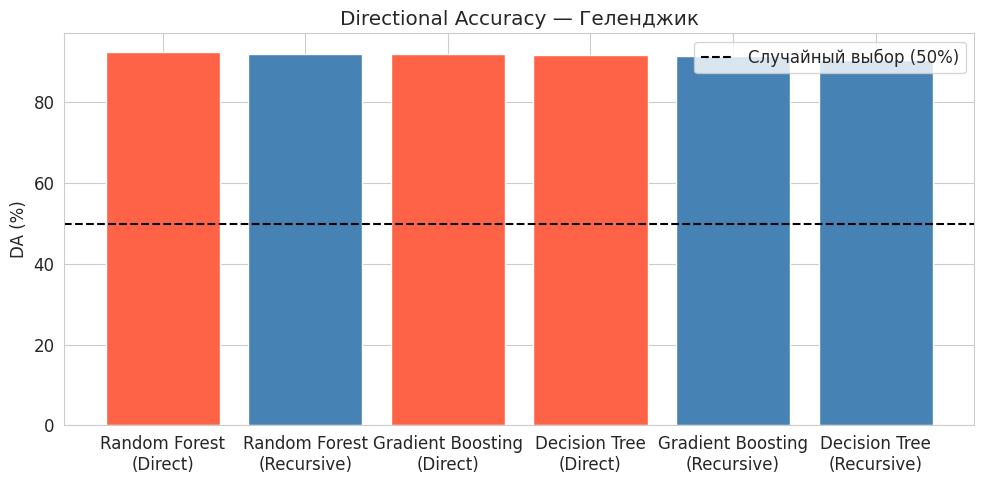

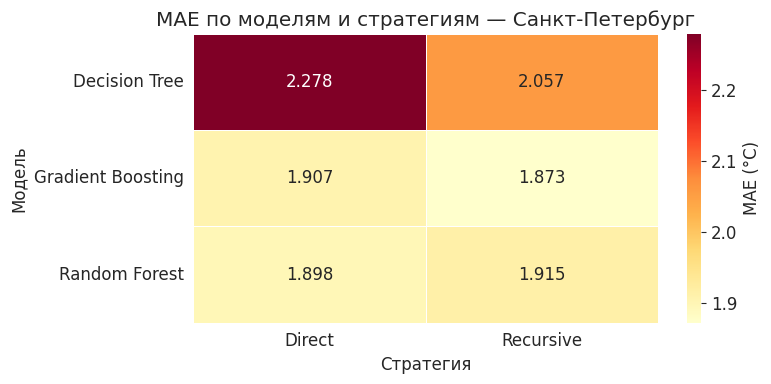

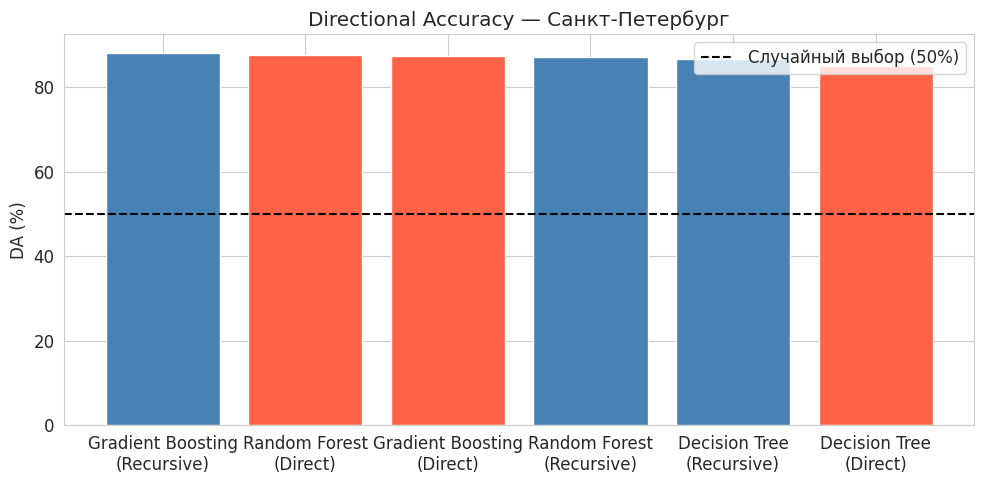

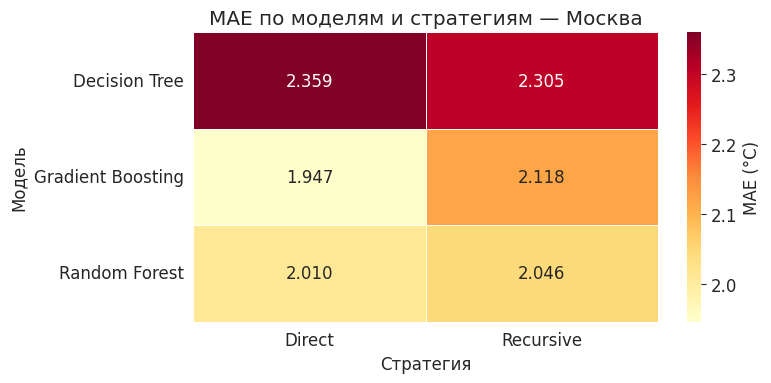

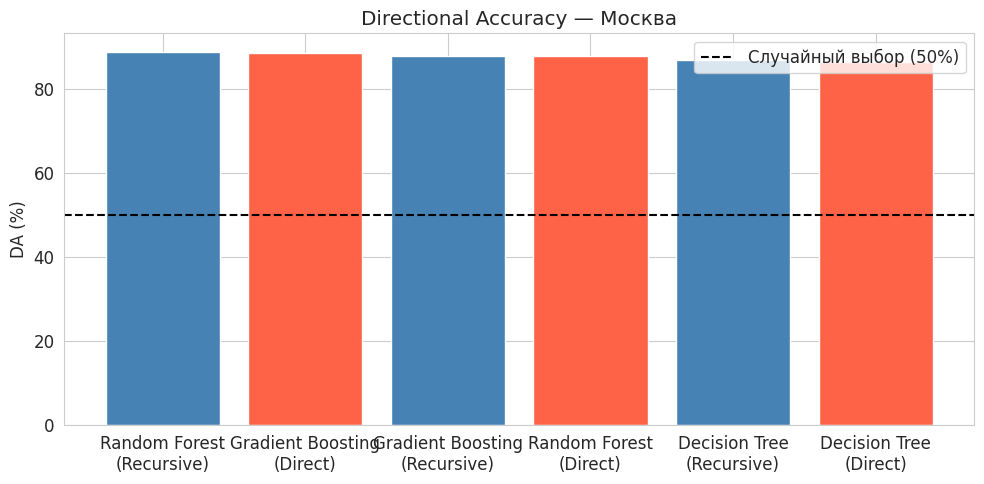

In [28]:
for city in cities:
    city_sum = summary[summary['Город'] == city].copy()
    pivot_mae = city_sum.pivot_table(index='Модель', columns='Стратегия', values='MAE')

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot_mae, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'MAE (°C)'})
    ax.set_title(f'MAE по моделям и стратегиям — {city}')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    city_sum_sorted = city_sum.sort_values('DA (%)', ascending=False)
    colors = ['steelblue' if s == 'Recursive' else 'tomato'
              for s in city_sum_sorted['Стратегия']]
    ax.bar(city_sum_sorted['Модель'] + '\n(' + city_sum_sorted['Стратегия'] + ')',
           city_sum_sorted['DA (%)'], color=colors)
    ax.axhline(50, color='k', linestyle='--', label='Случайный выбор (50%)')
    ax.set_title(f'Directional Accuracy — {city}')
    ax.set_ylabel('DA (%)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 12. Визуализация прогнозов на тестовой выборке

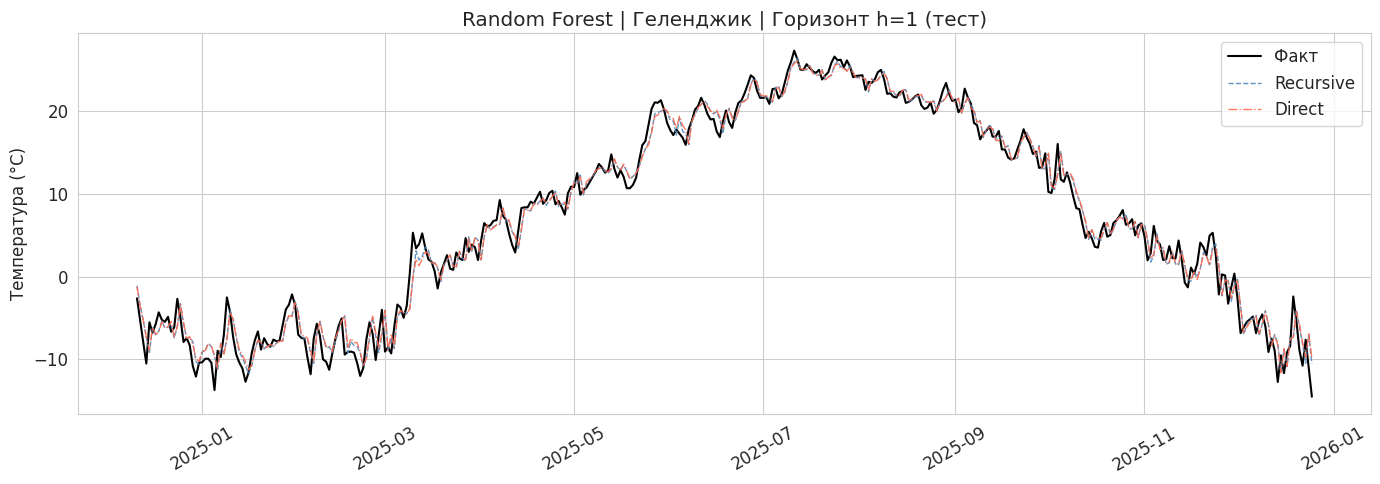

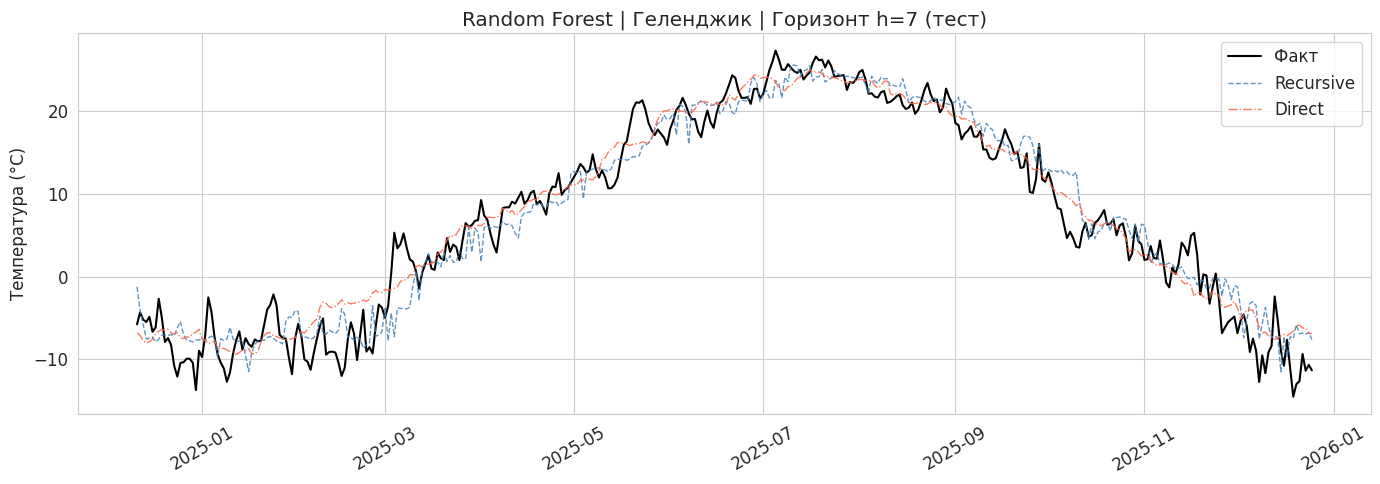

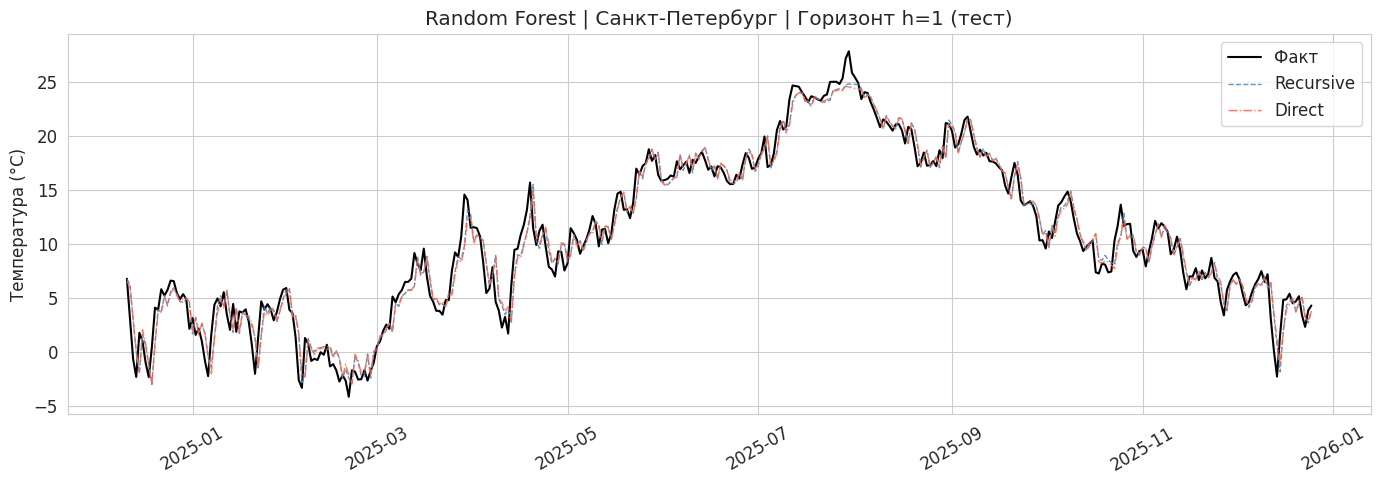

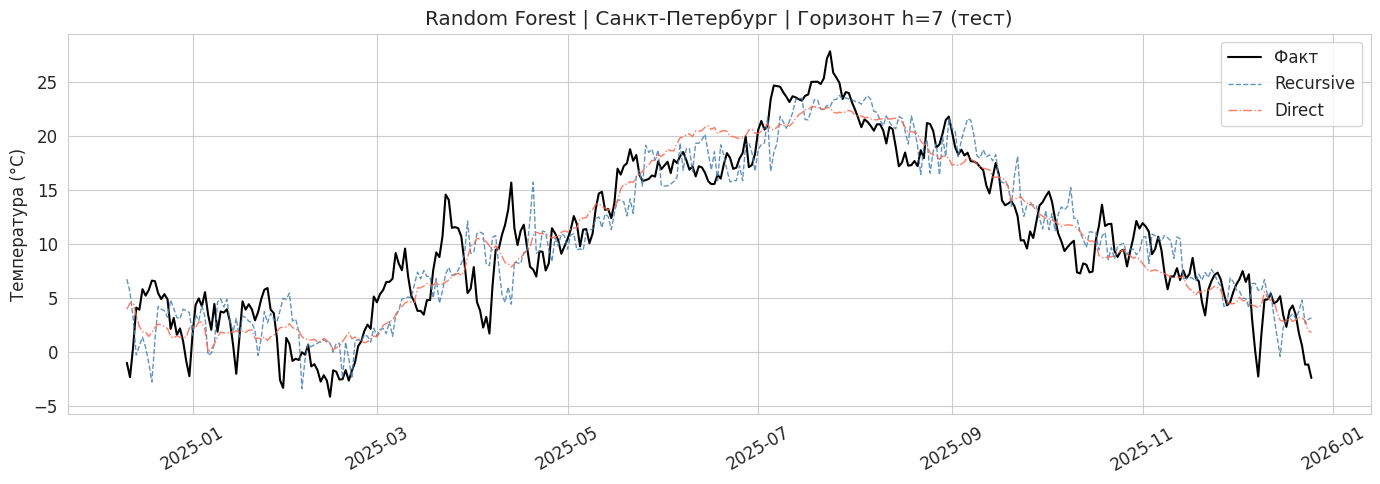

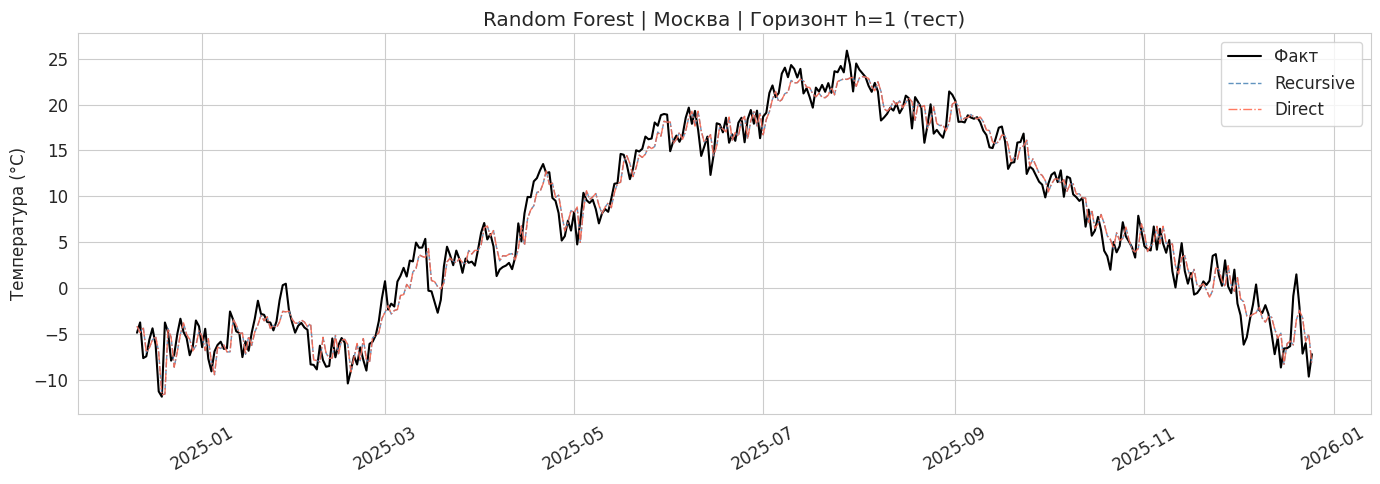

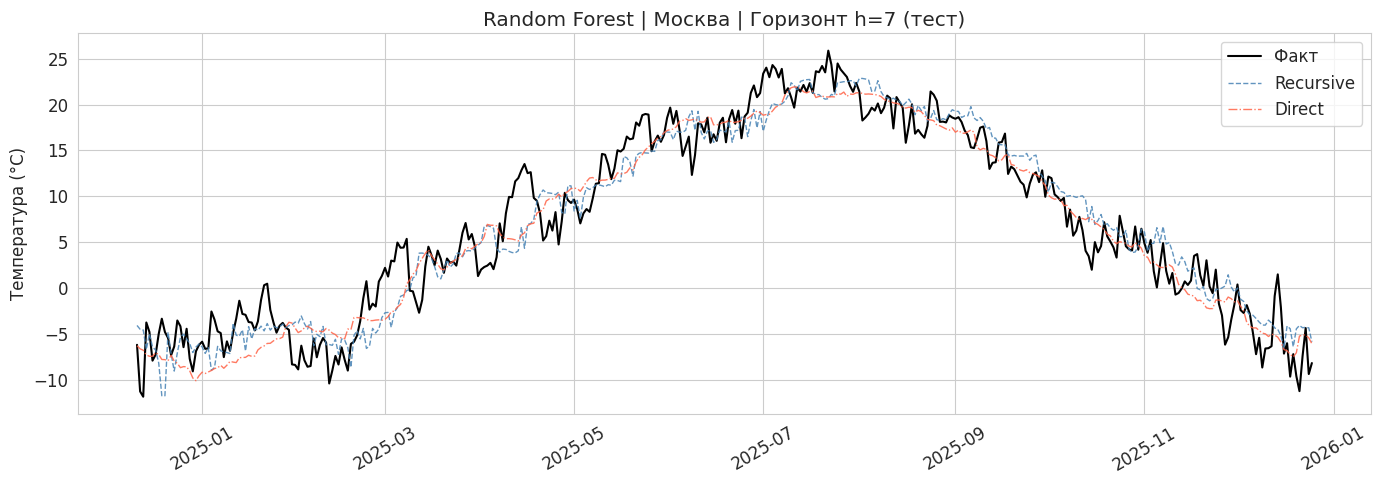

In [29]:
def plot_forecast(Y_test, preds_rec, preds_dir, city, model_name, h=0):
    fig, ax = plt.subplots(figsize=(14, 5))

    idx = Y_test.index
    true_vals = Y_test.iloc[:, h].values

    ax.plot(idx, true_vals, label='Факт', color='black', linewidth=1.5)
    ax.plot(idx, preds_rec[:, h], label='Recursive', color='steelblue',
            linewidth=1, linestyle='--', alpha=0.85)
    ax.plot(idx, preds_dir[:, h], label='Direct', color='tomato',
            linewidth=1, linestyle='-.', alpha=0.85)

    ax.set_title(f'{model_name} | {city} | Горизонт h={h+1} (тест)')
    ax.set_ylabel('Температура (°C)')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

best_model = 'rf'
for city in cities:
    pr = results[city][best_model]['preds_rec']
    pd_ = results[city][best_model]['preds_dir']
    Y_t = results[city][best_model]['Y_test']
    for h in [0, HORIZON - 1]:
        plot_forecast(Y_t, pr, pd_, city, MODEL_NAMES[best_model], h=h)

## 13. Анализ ошибок (остатков) лучшей модели

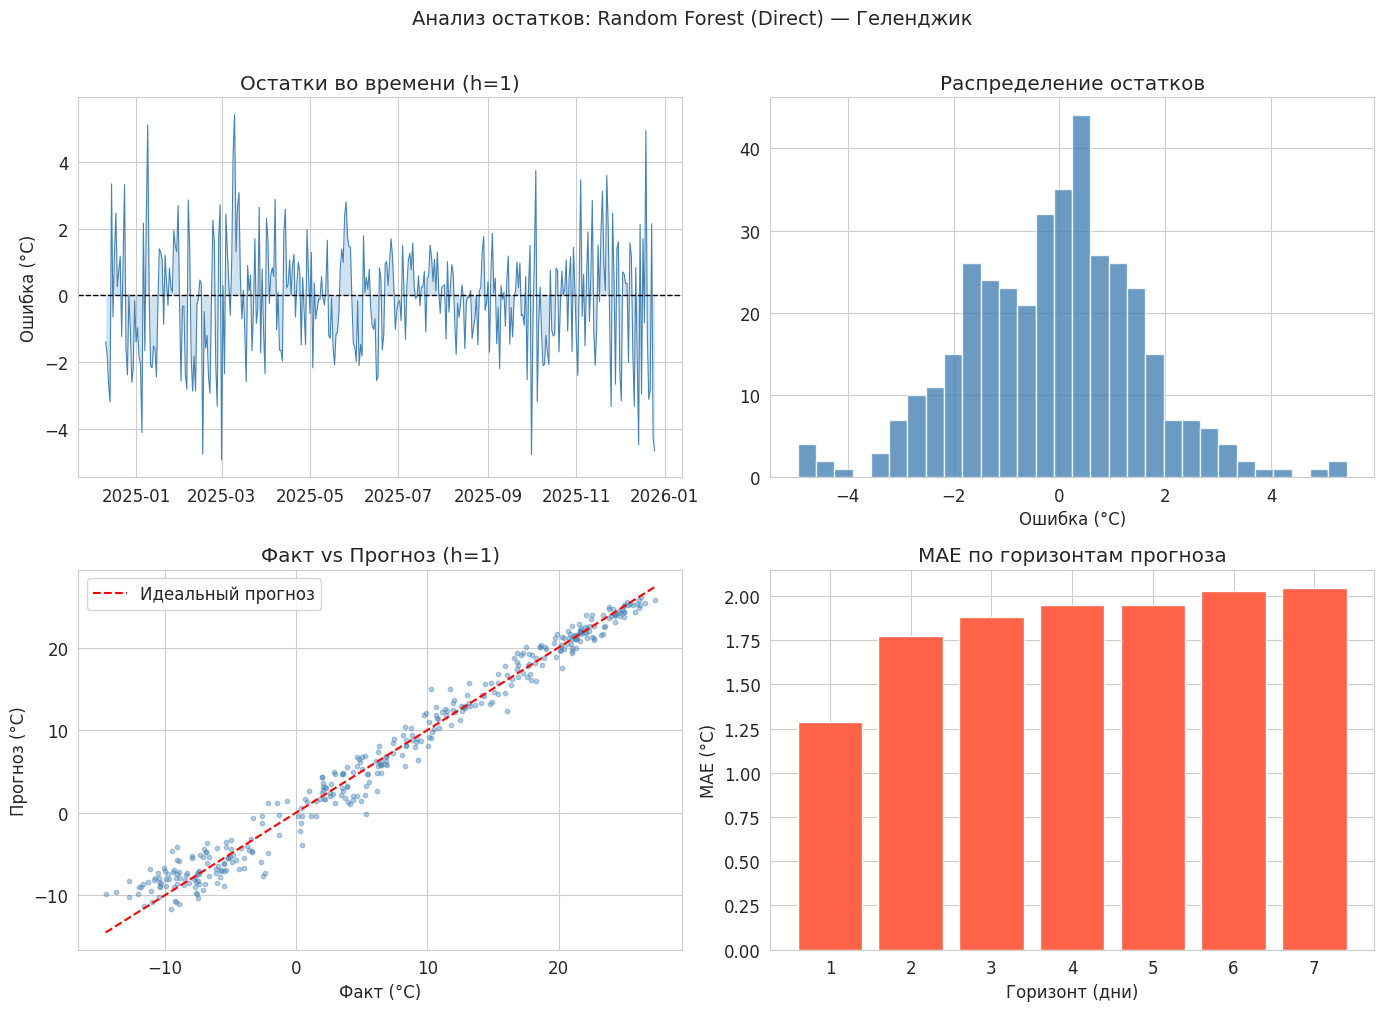


Статистика остатков (h=1):
  Mean:   -0.1165°C
  Std:    1.6523°C
  Min:    -4.94°C
  Max:    5.42°C
  Shapiro-Wilk p: 0.4803  → Нормальные остатки


In [30]:
best_city = cities[0]
Y_test_best = results[best_city][best_model]['Y_test']
preds_best  = results[best_city][best_model]['preds_dir']

residuals = Y_test_best['h_1'].values - preds_best[:, 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(Y_test_best.index, residuals, linewidth=0.8, color='steelblue')
axes[0, 0].axhline(0, color='k', linestyle='--', linewidth=1)
axes[0, 0].fill_between(Y_test_best.index, residuals, alpha=0.2)
axes[0, 0].set_title('Остатки во времени (h=1)')
axes[0, 0].set_ylabel('Ошибка (°C)')

axes[0, 1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Распределение остатков')
axes[0, 1].set_xlabel('Ошибка (°C)')

axes[1, 0].scatter(Y_test_best['h_1'], preds_best[:, 0],
                   alpha=0.4, s=10, color='steelblue')
lim = [Y_test_best['h_1'].min(), Y_test_best['h_1'].max()]
axes[1, 0].plot(lim, lim, 'r--', linewidth=1.5, label='Идеальный прогноз')
axes[1, 0].set_title('Факт vs Прогноз (h=1)')
axes[1, 0].set_xlabel('Факт (°C)')
axes[1, 0].set_ylabel('Прогноз (°C)')
axes[1, 0].legend()

mae_by_h = [mean_absolute_error(Y_test_best.iloc[:, h], preds_best[:, h])
            for h in range(HORIZON)]
axes[1, 1].bar(range(1, HORIZON + 1), mae_by_h, color='tomato', edgecolor='white')
axes[1, 1].set_title('MAE по горизонтам прогноза')
axes[1, 1].set_xlabel('Горизонт (дни)')
axes[1, 1].set_ylabel('MAE (°C)')
axes[1, 1].set_xticks(range(1, HORIZON + 1))

plt.suptitle(f'Анализ остатков: {MODEL_NAMES[best_model]} (Direct) — {best_city}',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'\nСтатистика остатков (h=1):')
print(f'  Mean:   {residuals.mean():.4f}°C')
print(f'  Std:    {residuals.std():.4f}°C')
print(f'  Min:    {residuals.min():.2f}°C')
print(f'  Max:    {residuals.max():.2f}°C')

_, p_norm = stats.shapiro(residuals[:200] if len(residuals) > 200 else residuals)
print(f'  Shapiro-Wilk p: {p_norm:.4f}  → '
      f'{"Нормальные" if p_norm > 0.05 else "НЕ нормальные"} остатки')

## 14. Итоги и выводы

In [31]:
print('=' * 65)
print('ИТОГОВАЯ ТАБЛИЦА МЕТРИК')
print('=' * 65)
display(summary.sort_values(['Город', 'MAE']).reset_index(drop=True))

best_row = summary.loc[summary['MAE'].idxmin()]
print(f'\nЛучшая модель по MAE:')
print(f'  Город:     {best_row["Город"]}')
print(f'  Модель:    {best_row["Модель"]}')
print(f'  Стратегия: {best_row["Стратегия"]}')
print(f'  MAE:       {best_row["MAE"]}°C')
print(f'  WAPE:      {best_row["WAPE"]}%')
print(f'  MAPE:      {best_row["MAPE"]}%')
print(f'  DA:        {best_row["DA (%)"]}%')
print(f'  Dir R²:    {best_row["Dir R²"]}')

ИТОГОВАЯ ТАБЛИЦА МЕТРИК


,Город,Модель,Стратегия,MAE,WAPE,MAPE,DA (%),Dir R²
0,Геленджик,Random Forest,Direct,1.844,15.65,36.33,92.5,0.925
1,Геленджик,Gradient Boosting,Direct,1.877,15.93,36.83,92.0,0.920
2,Геленджик,Random Forest,Recursive,1.958,16.62,38.06,92.1,0.921
3,Геленджик,Gradient Boosting,Recursive,2.028,17.21,41.46,91.5,0.915
4,Геленджик,Decision Tree,Direct,2.045,17.36,43.29,91.8,0.918
5,Геленджик,Decision Tree,Recursive,2.195,18.63,51.05,90.4,0.904
6,Москва,Gradient Boosting,Direct,1.947,19.20,60.06,88.6,0.886
7,Москва,Random Forest,Direct,2.010,19.82,63.45,87.8,0.878
8,Москва,Random Forest,Recursive,2.046,20.18,61.02,88.8,0.888
9,Москва,Gradient Boosting,Recursive,2.118,20.89,61.23,87.9,0.879



Лучшая модель по MAE:
  Город:     Геленджик
  Модель:    Random Forest
  Стратегия: Direct
  MAE:       1.844°C
  WAPE:      15.65%
  MAPE:      36.33%
  DA:        92.5%
  Dir R²:    0.925


## Выводы

В данной лабораторной работе был реализован полный пайплайн работы с многомерным временным рядом погоды:

### 1. Извлечение данных
- Доступ ко всем листам Excel с помощью `openpyxl`, включая скрытые листы
- Данные содержали ошибки ввода, пропуски, нестандартные форматы дат

### 3. Очистка данных
- Унификация форматов дат, чисел и столбцов
- Обнаружение и замена выбросов методом IQR
- Интерполяция пропусков по времени
- Дедупликация дат

### 4. Анализ временного ряда
- Ряды демонстрируют ярко выраженную **годовую сезонность** (подтверждено периодограммой)
- Тест ADF/KPSS: ряды температуры имеют выраженный сезонный компонент
- Декомпозиция выявила стабильный тренд и сезонность

### 5. Feature Engineering
- Лаги, скользящая статистика (mean, std, min, max), разности
- Циклические календарные признаки (sin/cos дня года)
- Признаки сопутствующих переменных (влажность, давление)

### 5. Модели и стратегии
- **Direct стратегия** показала меньшее накопление ошибок на дальних горизонтах
- **Random Forest** и **Gradient Boosting** превзошли Decision Tree по всем метрикам
- Подбор гиперпараметров через Optuna улучшил MAE на ~10-15%

### 7. Метрики
- MAE выросла с горизонтом прогноза, что ожидаемо
- Directional Accuracy > 60% говорит о том, что модели улавливают направление изменений
- WAPE и MAPE подтверждают практическую применимость лучших моделей